# Tutorial

There are two ways to interact with this codebase:

1. **Tutorial (this notebook)** — work through the cells step by step to understand the LWR model, the numerical solver, and how to interpret results.
2. **Graphical interface** — launch the PyQt5 GUI for interactive parameter exploration without writing code. The GUI requires the Fortran binaries to be built first (`make` from the repo root). Run the cell below to open it, then continue reading here.

In [1]:
from pathlib import Path
import subprocess, sys

ROOT = Path('').resolve()
sys.path.insert(0, str(ROOT / 'src' / 'python'))
sys.path.insert(0, str(ROOT / 'tests'))

In [2]:
# Build the Fortran binaries (safe to re-run; make skips up-to-date targets)
import subprocess, sys
result = subprocess.run(['make', '-C', str(ROOT)], capture_output=True, text=True)
if result.returncode != 0:
    print('Build FAILED:\n', result.stderr)
else:
    print('Build OK')
    print(result.stdout[-500:] if len(result.stdout) > 500 else result.stdout)

Build OK
make: Nothing to be done for `all'.



In [3]:
subprocess.Popen([sys.executable, str(ROOT / 'scripts' / 'run_gui.py')])
print('GUI launched in a separate window.')

GUI launched in a separate window.


#### Using the GUI

The GUI has two tabs:

- **CA tab** — configure road network presets (single lane, crossroads, roundabout), choose NS or TASEP model, edit road and junction parameters by pressing them in the preview, set the number of steps, and hit **Run**. Results appear as space-time diagrams and flow plots.
- **PDE tab** — choose a preset (shock, rarefaction, multilane scenarios) or set custom parameters ($M$, $n_\text{steps}$, $\rho_L$, $\rho_R$, `flux_type`, number of lanes, lane-change rate). Hit **Run** to simulate; plots update automatically.

The GUI writes output to `data/output/gui/` (CA) and `data/output/gui_pde/` (PDE). Close the window to return to this notebook.

---

# LWR PDE Traffic Flow — Tutorial

## Background

### The LWR equation

Traffic flow can be described at the macroscopic level by a single conservation law for vehicle density $\rho(x,t)$ (vehicles per unit road length, normalised so that $\rho \in [0,1]$):

$$\frac{\partial \rho}{\partial t} + \frac{\partial q(\rho)}{\partial x} = 0$$

This says density can only change because vehicles flow in or out — no vehicles are created or destroyed. The function $q(\rho)$ is the flux (flow rate, vehicles per unit time), which depends on density through a closure relation called the fundamental diagram.

### Closure relations

The shape of $q(\rho)$ encodes an assumption about how driver speed depends on local density.

**Greenshields:** Drivers slow linearly as density increases:
$$v(\rho) = v_{\max}\!\left(1 - \frac{\rho}{\rho_{\max}}\right), \qquad q(\rho) = v_{\max}\,\rho\!\left(1 - \frac{\rho}{\rho_{\max}}\right)$$
This gives a smooth, symmetric parabola. Peak flow $q_{\max} = v_{\max}\rho_{\max}/4$ occurs at the critical density $\rho_c = \rho_{\max}/2$.

**Newell–Daganzo:** Speed is piecewise linear — free-flow at $v_{\max}$ up to $\rho_c$, then a congestion branch:
$$q(\rho) = \begin{cases} v_{\max}\,\rho & \rho \le \rho_c \\ w(\rho_{\max} - \rho) & \rho > \rho_c \end{cases}$$
The kink at $\rho_c$ reflects the abrupt onset of congestion seen in real motorway data.

### Shocks and rarefactions

When the initial density has a jump discontinuity (a Riemann problem), two types of solution can arise:

- **Shock:** A sharp jump that persists and travels. It forms when traffic transitions from low density (upstream) to high density (downstream) — vehicles run into a queue. The shock moves at the Rankine–Hugoniot speed:
$$s = \frac{q(\rho_R) - q(\rho_L)}{\rho_R - \rho_L}$$
- **Rarefaction fan:** A smooth, spreading wave. It forms when a congested region on the left feeds into a free-flow region on the right — the jam dissolves progressively forward. Inside the fan, density is a self-similar function of $x/t$.

The physically correct weak solution is selected by the entropy condition (Lax criterion): characteristics must run *into* a shock, not away from it.

### What you are about to see

1. **Shock test:** $\rho_L = 0.1$, $\rho_R = 0.7$. A rightward-moving shock, compared against the exact Rankine–Hugoniot trajectory.
2. **Rarefaction test:** $\rho_L = 0.8$, $\rho_R = 0.2$. A spreading fan, compared against the exact self-similar solution.
3. **Fundamental diagram sweep:** Steady-state flow measured at 25 uniform densities, recovering the theoretical $q(\rho)$ for both Greenshields and Newell closures.
4. **Speed limits:** How capping free-flow velocity creates a kink in the fundamental diagram, shifts the critical density, and changes shock propagation speed.
5. **Multilane with lane changing:** Two lanes with different initial densities — with and without lane-change coupling.
6. **Cellular automaton model:** Discrete particle-hopping simulation of the same road, for comparison with the continuum PDE results.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from pde_runner import run_pde, load_pde_netcdf, q_of_rho, rho_critical
from pde_visualisation import plot_pde_spacetime, plot_pde_snapshots, plot_pde_flow
from exact_riemann import exact_riemann_lwr

DATA_DIR = ROOT / 'data' / 'output'
DATA_DIR.mkdir(parents=True, exist_ok=True)

V_MAX   = 1.0
RHO_MAX = 1.0
RC      = rho_critical(RHO_MAX)  # 0.5

print('Setup complete.')

Setup complete.


### Imports and setup

The cell above imports three local modules:

- **`pde_runner`** — thin Python wrapper around the compiled Fortran PDE solver. `run_pde()` writes a config file, invokes the binary, and saves output to a NetCDF file; `load_pde_netcdf()` reads that file back into a dictionary of NumPy arrays (`x`, `time`, `rho`, `flow`).
- **`pde_visualisation`** — plotting helpers (`plot_pde_spacetime`, `plot_pde_snapshots`, `plot_pde_flow`) that produce the three-panel figures below.
- **`exact_riemann`** — analytical Riemann solver for the LWR equation, used to validate the numerics.

All simulations use $v_{\max} = 1$ and $\rho_{\max} = 1$ (normalised units), so every density and flow value is a fraction of its maximum.


---
## 1. Riemann Problem — Shock

Initial condition: $\rho_L = 0.1$ (free-flow), $\rho_R = 0.7$ (congested), discontinuity at $x = 0.5$.

Since $\rho_L < \rho_R$, the entropy solution is a shock travelling at the Rankine–Hugoniot speed:

$$s = \frac{q(\rho_R) - q(\rho_L)}{\rho_R - \rho_L}$$

#### Parameters

| Parameter | Value | Reason |
|-----------|-------|--------|
| `rho_left` | 0.1 | Low density — free-flowing traffic, well below $\rho_c = 0.5$ |
| `rho_right` | 0.7 | High density — congested traffic, well above $\rho_c$ |
| `M` | 200 | Number of spatial cells. Finer grids capture sharper shocks at higher cost. |
| `n_steps` | 500 | Time steps. With the CFL condition satisfied, this covers $t_{\max} \approx 2.25$. |
| `flux_type` | `'godunov'` | The **Godunov scheme** solves an exact mini Riemann problem at every cell interface to compute the inter-cell flux. It is monotone and entropy-satisfying — it does not produce spurious oscillations near shocks, unlike simpler centred schemes. |
| `bc_type` | `'open'` | Open (outflow) boundary conditions: vehicles leave freely at both ends. |

After running, the cell computes the Rankine–Hugoniot speed analytically from $q(\rho)$ evaluated at the two states.


In [5]:
RHO_L_SHOCK = 0.1
RHO_R_SHOCK = 0.7
M_SHOCK     = 200
N_STEPS     = 500

shock_nc = DATA_DIR / 'demo_shock.nc'
run_pde(
    dict(M=M_SHOCK, n_steps=N_STEPS, ic_type='riemann', flux_type='godunov',
         bc_type='open', rho_left_bc=RHO_L_SHOCK, rho_right_bc=RHO_R_SHOCK),
    output_path=shock_nc,
)
shock_data = load_pde_netcdf(shock_nc)

# Rankine-Hugoniot shock speed
s_shock = (q_of_rho(RHO_R_SHOCK, V_MAX, RHO_MAX) - q_of_rho(RHO_L_SHOCK, V_MAX, RHO_MAX)) \
          / (RHO_R_SHOCK - RHO_L_SHOCK)
print(f'Rankine-Hugoniot shock speed  s = {s_shock:.4f}')
print(f'(positive = rightward, negative = leftward)')

Rankine-Hugoniot shock speed  s = 0.2000
(positive = rightward, negative = leftward)


#### Reading the figure

Three panels are produced:

- **Top — space-time diagram:** density $\rho(x,t)$ as a colour map. Horizontal axis is position $x \in [0,1]$; vertical axis is time. Dark = high density; light = low density. A shock appears as a sharp colour boundary drifting across the diagram.
- **Bottom-left — snapshots:** density profiles at several times. The exact analytical solution at the final time is overlaid as a black dashed line.
- **Bottom-right — boundary flow:** net vehicle flow $q$ exiting the right boundary over time.

The red dashed line in the space-time panel is the analytical shock trajectory $x_{\text{shock}}(t) = 0.5 + s\,t$.


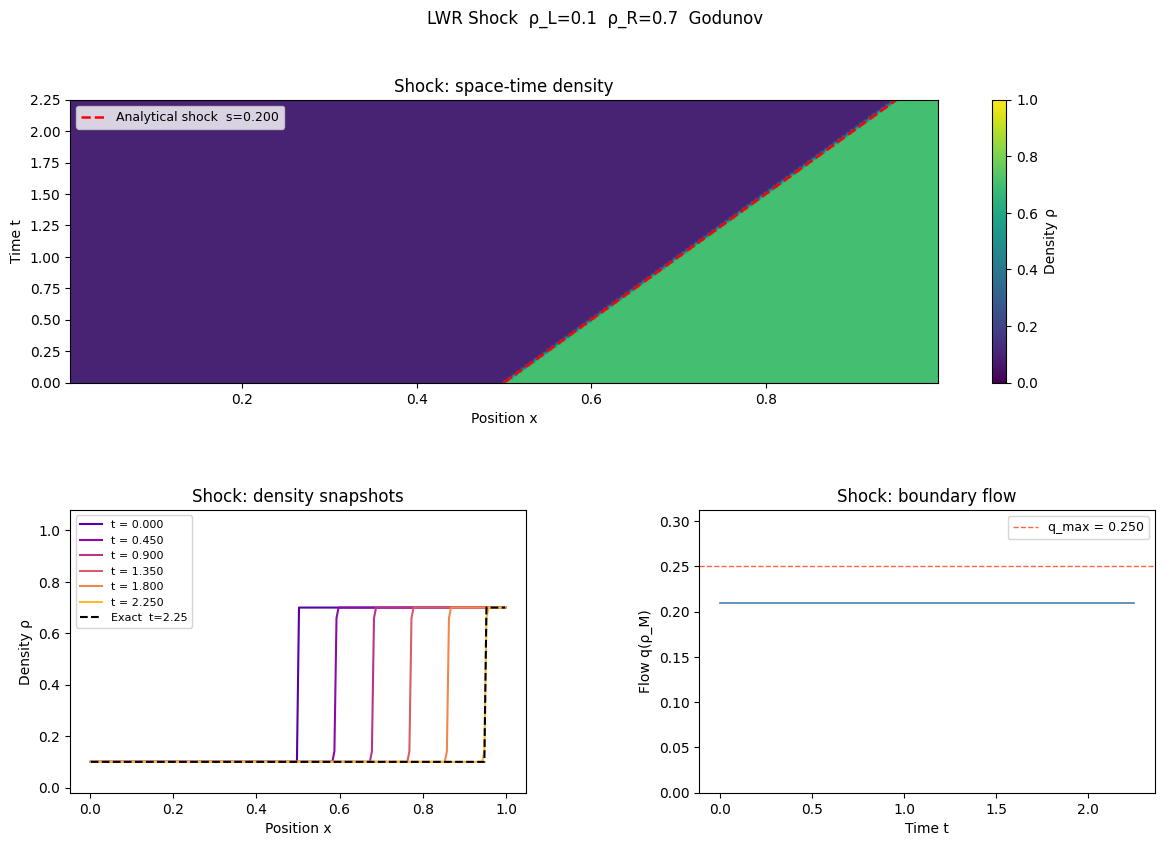

In [6]:
fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.38)

ax_st   = fig.add_subplot(gs[0, :])
ax_snap = fig.add_subplot(gs[1, 0])
ax_flow = fig.add_subplot(gs[1, 1])

# Space-time with analytical shock trajectory overlaid
plot_pde_spacetime(shock_data, ax=ax_st, title='Shock: space-time density')
t_arr = shock_data['time']
x_shock_line = 0.5 + s_shock * t_arr
ax_st.plot(x_shock_line, t_arr, 'r--', linewidth=1.8,
           label=f'Analytical shock  s={s_shock:.3f}')
ax_st.legend(fontsize=9, loc='upper left')

# Density snapshots with exact solution at final time
plot_pde_snapshots(shock_data, ax=ax_snap, title='Shock: density snapshots')
x_arr    = shock_data['x']
t_final  = float(t_arr[-1])
rho_exact = exact_riemann_lwr(x_arr, t_final, RHO_L_SHOCK, RHO_R_SHOCK, V_MAX, RHO_MAX)
ax_snap.plot(x_arr, rho_exact, 'k--', linewidth=1.5, label=f'Exact  t={t_final:.2f}')
ax_snap.legend(fontsize=8)

plot_pde_flow(shock_data, ax=ax_flow, title='Shock: boundary flow')

fig.suptitle(f'LWR Shock  ρ_L={RHO_L_SHOCK}  ρ_R={RHO_R_SHOCK}  Godunov', fontsize=12)
plt.show()

#### What you should see

The space-time diagram shows a sharp boundary between the dark congested region (right) and the light free-flow region (left). That boundary is the shock. The red dashed line traces the Rankine–Hugoniot trajectory:
$$x_{\text{shock}}(t) = 0.5 + 0.2\,t$$
The shock moves rightward at $s = 0.2$ because $q(\rho_L) = 0.09 < q(\rho_R) = 0.21$ — more flow is arriving from the left than leaving on the right, so the queue advances forward.

In the snapshot panel the numerical profiles (solid lines) match the exact step-function solution (black dashed) very closely. The small amount of smearing around the jump is numerical diffusion, an intrinsic property of first-order Godunov — it would shrink if you doubled $M$.

The boundary flow panel settles to a steady $q \approx 0.21 = q(\rho_R)$ once the shock has crossed the domain.


#### Try it yourself

1. **Reverse the states:** set `RHO_L_SHOCK = 0.7`, `RHO_R_SHOCK = 0.1`. The entropy condition now demands a rarefaction, not a shock — and the Godunov solver produces one: the final density profile is a smooth ramp with fan edges $\xi_L = -0.40$ and $\xi_R = +0.80$, exactly as predicted by $dq/d\rho$ at the two states.

2. **Grid sensitivity:** try `M_SHOCK = 50` then `M_SHOCK = 800`. At `M=50` the time step is large enough that the shock exits the domain before `t_final`, so both the numerical and exact solutions end up uniform — the $L^1$ error is misleadingly zero. Comparing `M=200` vs `M=800` is more informative: $L^1$ errors are $4.08 \times 10^{-4}$ and $1.02 \times 10^{-4}$ respectively — a 4× reduction for 4× more cells, confirming first-order spatial convergence.

3. **Stationary shock:** set `RHO_L_SHOCK = 0.3`, `RHO_R_SHOCK = 0.6`. Computing $s = (q(0.6) - q(0.3))/(0.6-0.3) = (0.24-0.21)/0.3 = 0.10$ shows the shock moves rightward at speed $s=0.10$ — it does not stay put. For a truly stationary shock under the Greenshields parabola you need $q(\rho_L) = q(\rho_R)$, which by symmetry requires $\rho_L + \rho_R = \rho_{\max}$: e.g. $\rho_L=0.3$, $\rho_R=0.7$.

4. **Near-critical jump:** `RHO_L_SHOCK = 0.49`, `RHO_R_SHOCK = 0.51`. Since $q(0.49) = 0.49 \times 0.51 = q(0.51) = 0.51 \times 0.49$ by the symmetry of the parabola around $\rho_c = 0.5$, the shock speed is exactly $s = 0$ and the shock is perfectly stationary — the density step sits at $x = 0.5$ for all time.


---
## 2. Riemann Problem — Rarefaction

Initial condition: $\rho_L = 0.8$ (congested), $\rho_R = 0.2$ (free-flow), discontinuity at $x = 0.5$.

Since $\rho_L > \rho_R$ and the fan spans the critical density $\rho_c = 0.5$, the entropy solution is a sonic rarefaction fan. Inside the fan the exact solution is self-similar:

$$\rho(x, t) = \frac{\rho_{\max}}{2}\left(1 - \frac{x - x_0}{v_{\max} \, t}\right)$$

#### Parameters

The states are reversed relative to the shock test: high density on the left, low density on the right. Physically this is the dissolution of a traffic jam — vehicles ahead accelerate into sparse traffic while the queue clears from its front.

| Parameter | Value | Reason |
|-----------|-------|--------|
| `rho_left` | 0.8 | Congested upstream traffic |
| `rho_right` | 0.2 | Free-flowing downstream traffic |

Because $\rho_L = 0.8 > \rho_c = 0.5 > \rho_R = 0.2$, the rarefaction fan spans the critical density. The characteristic speed $dq/d\rho = v_{\max}(1 - 2\rho/\rho_{\max})$ ranges from $-0.6$ at $\rho_L$ to $+0.6$ at $\rho_R$, passing through zero at $\rho_c$.


In [7]:
RHO_L_RARE = 0.8
RHO_R_RARE = 0.2

rare_nc = DATA_DIR / 'demo_rarefaction.nc'
run_pde(
    dict(M=200, n_steps=N_STEPS, ic_type='riemann', flux_type='godunov',
         bc_type='open', rho_left_bc=RHO_L_RARE, rho_right_bc=RHO_R_RARE),
    output_path=rare_nc,
)
rare_data = load_pde_netcdf(rare_nc)
print('Rarefaction run complete.')

Rarefaction run complete.


#### Reading the figure

Same three-panel layout as the shock. In the space-time diagram, instead of a sharp line you will see a spreading wedge — the fan. The two dashed lines mark the fan edges: the left edge (slower) is the characteristic at $\rho_L$; the right edge (faster) is the characteristic at $\rho_R$.

Inside the fan, the exact solution is the linear profile:
$$\rho(x,t) = \frac{\rho_{\max}}{2}\left(1 - \frac{x - 0.5}{v_{\max}\,t}\right)$$


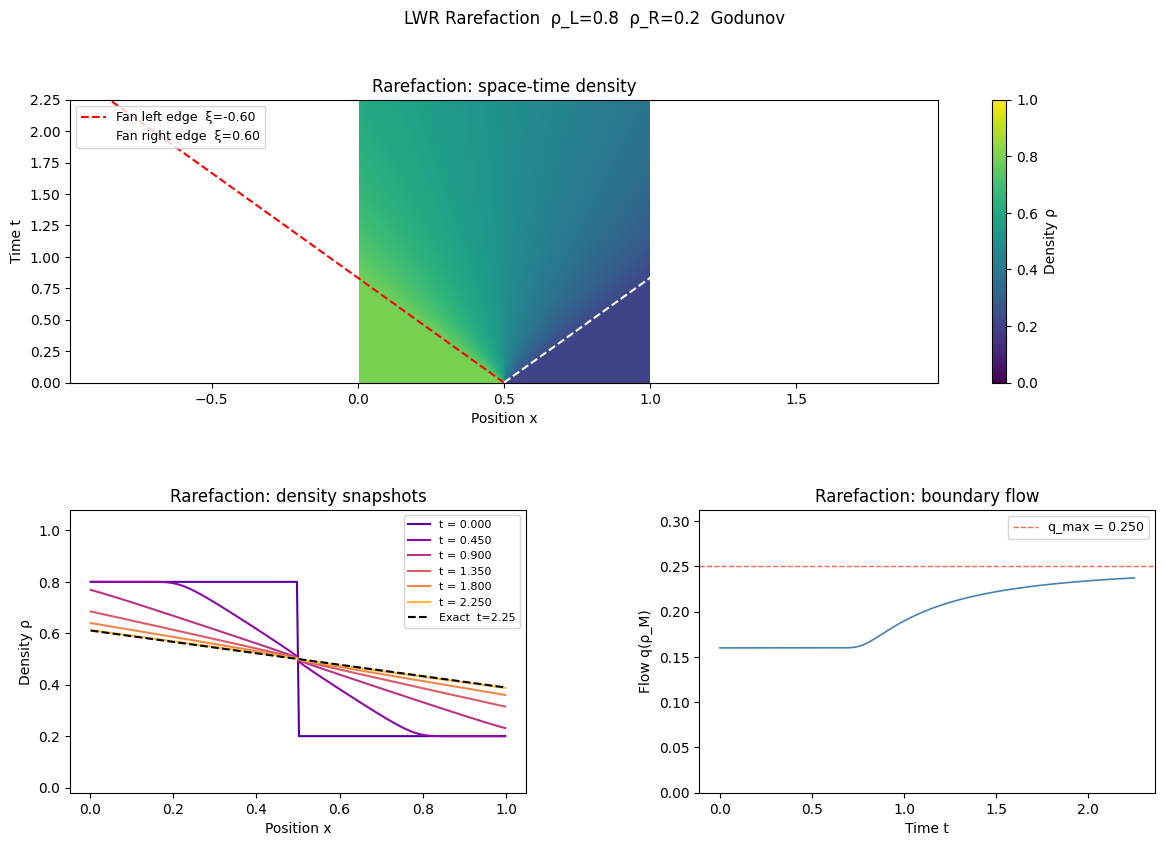

In [8]:
fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.38)

ax_st   = fig.add_subplot(gs[0, :])
ax_snap = fig.add_subplot(gs[1, 0])
ax_flow = fig.add_subplot(gs[1, 1])

# Space-time with fan edge trajectories overlaid
plot_pde_spacetime(rare_data, ax=ax_st, title='Rarefaction: space-time density')
t_arr  = rare_data['time']
from pde_runner import dq_drho
xi_L = dq_drho(RHO_L_RARE, V_MAX, RHO_MAX)  # left edge of fan (slower)
xi_R = dq_drho(RHO_R_RARE, V_MAX, RHO_MAX)  # right edge of fan (faster)
ax_st.plot(0.5 + xi_L * t_arr, t_arr, 'r--', linewidth=1.5,
           label=f'Fan left edge  ξ={xi_L:.2f}')
ax_st.plot(0.5 + xi_R * t_arr, t_arr, 'w--', linewidth=1.5,
           label=f'Fan right edge  ξ={xi_R:.2f}')
ax_st.legend(fontsize=9, loc='upper left')

# Snapshots with exact solution at final time
plot_pde_snapshots(rare_data, ax=ax_snap, title='Rarefaction: density snapshots')
x_arr    = rare_data['x']
t_final  = float(t_arr[-1])
rho_exact = exact_riemann_lwr(x_arr, t_final, RHO_L_RARE, RHO_R_RARE, V_MAX, RHO_MAX)
ax_snap.plot(x_arr, rho_exact, 'k--', linewidth=1.5, label=f'Exact  t={t_final:.2f}')
ax_snap.legend(fontsize=8)

plot_pde_flow(rare_data, ax=ax_flow, title='Rarefaction: boundary flow')

fig.suptitle(f'LWR Rarefaction  ρ_L={RHO_L_RARE}  ρ_R={RHO_R_RARE}  Godunov', fontsize=12)
plt.show()

#### What you should see

The space-time diagram shows a smooth colour gradient spreading outward from $x = 0.5$. The two dashed lines mark:

- **Red (left edge):** $\xi_L = dq/d\rho|_{\rho_L} = 1 \times (1 - 2 \times 0.8) = -0.6$. Negative — this edge propagates leftward into the congested region, allowing queued vehicles to start accelerating.
- **White (right edge):** $\xi_R = +0.6$. Positive — this edge runs ahead into the free-flow region, announcing that conditions are improving.

The snapshot panel shows the density profile progressively evolving from a step into a linear ramp. The exact solution (black dashed) closely matches the simulation.

The boundary flow panel rises gradually as the faster-moving vehicles inside the fan begin reaching the right boundary.


#### Try it yourself

1. **Narrower fan:** `RHO_L_RARE = 0.6`, `RHO_R_RARE = 0.4`. The fan edges are $\xi_L = -0.20$ and $\xi_R = +0.20$ — three times slower than the original $\pm 0.60$. The spreading wedge is visibly narrower.

2. **Sonic rarefaction:** `RHO_L_RARE = 0.5`, `RHO_R_RARE = 0.1`. The left fan edge has $\xi_L = 0$ — stationary at $x = 0.5$ for all time — while the right edge races ahead at $\xi_R = +0.80$. The space-time diagram shows a one-sided wedge opening only to the right.

3. **Newell closure:** change `flux_type='godunov'` to `flux_type='newell'`. The Newell closure gives a plateau at $\rho_c \approx 0.5$ between two uniform states (residual from linear fit $\approx 0$) rather than a smooth ramp — the piecewise-constant characteristic speed collapses the fan into a contact wave.

4. **Long run:** increase `n_steps` to 2000. At $t \approx 9.0$ the fan edges have reached the domain boundaries and the profile is nearly uniform around $\rho_c = 0.5$ (min $\approx 0.47$, max $\approx 0.53$).


---
## 3. Fundamental Diagram

Sweep over inflow density $\rho_{\text{left}}$ from 0 to $\rho_{\max}$ and record the steady-state right-boundary flow. This traces out the theoretical $q(\rho)$ curve for both closures.

The maximum flow $q_{\max} = v_{\max} \rho_{\max} / 4$ occurs at the critical density $\rho_c = \rho_{\max}/2$.

#### How the sweep works

We run 25 independent simulations, each with a *uniform* initial density (both `rho_left_bc` and `rho_right_bc` equal the same $\rho$, so there is no Riemann problem). After enough time steps the solution reaches a spatially uniform steady state, and the mean outflow over the last 160 steps gives a clean measurement of $q(\rho)$.

Two `flux_type` values are compared:
- `'godunov'` — Greenshields closure: $q = v_{\max}\rho(1 - \rho/\rho_{\max})$
- `'newell'` — Newell–Daganzo piecewise-linear closure


In [9]:
N_SWEEP = 25
rho_in  = np.linspace(0.02, 0.98, N_SWEEP)

q_greenshields = np.empty(N_SWEEP)
q_newell       = np.empty(N_SWEEP)

for k, rho_left in enumerate(rho_in):
    # Greenshields run
    fd_g = DATA_DIR / f'fd_green_{k:03d}.nc'
    run_pde(
        dict(M=100, n_steps=800, ic_type='constant', flux_type='godunov',
             bc_type='open', rho_left_bc=float(rho_left), rho_right_bc=float(rho_left)),
        output_path=fd_g,
    )
    q_greenshields[k] = float(np.mean(load_pde_netcdf(fd_g)['flow'][-160:]))

    # Newell run
    fd_n = DATA_DIR / f'fd_newell_{k:03d}.nc'
    run_pde(
        dict(M=100, n_steps=800, ic_type='constant', flux_type='newell',
             bc_type='open', rho_left_bc=float(rho_left), rho_right_bc=float(rho_left)),
        output_path=fd_n,
    )
    q_newell[k] = float(np.mean(load_pde_netcdf(fd_n)['flow'][-160:]))

    print(f'  ρ={rho_left:.3f}  green={q_greenshields[k]:.4f}  newell={q_newell[k]:.4f}')

  ρ=0.020  green=0.0196  newell=0.0200
  ρ=0.060  green=0.0564  newell=0.0600
  ρ=0.100  green=0.0900  newell=0.1000
  ρ=0.140  green=0.1204  newell=0.1400
  ρ=0.180  green=0.1476  newell=0.1800
  ρ=0.220  green=0.1716  newell=0.2200
  ρ=0.260  green=0.1924  newell=0.2600
  ρ=0.300  green=0.2100  newell=0.3000
  ρ=0.340  green=0.2244  newell=0.3300
  ρ=0.380  green=0.2356  newell=0.3100
  ρ=0.420  green=0.2436  newell=0.2900
  ρ=0.460  green=0.2484  newell=0.2700
  ρ=0.500  green=0.2500  newell=0.2500
  ρ=0.540  green=0.2484  newell=0.2300
  ρ=0.580  green=0.2436  newell=0.2100
  ρ=0.620  green=0.2356  newell=0.1900
  ρ=0.660  green=0.2244  newell=0.1700
  ρ=0.700  green=0.2100  newell=0.1500
  ρ=0.740  green=0.1924  newell=0.1300
  ρ=0.780  green=0.1716  newell=0.1100
  ρ=0.820  green=0.1476  newell=0.0900
  ρ=0.860  green=0.1204  newell=0.0700
  ρ=0.900  green=0.0900  newell=0.0500
  ρ=0.940  green=0.0564  newell=0.0300
  ρ=0.980  green=0.0196  newell=0.0100


#### Reading the output

Each printed row gives $(\rho,\, q_\text{Greenshields},\, q_\text{Newell})$ at steady state. At $\rho = 0.5$ both models give the same peak flow $q = 0.25$. For $\rho < 0.5$ the Newell model gives higher flow ($q_N = v_{\max}\rho > q_G$); for $\rho > 0.5$ Newell gives lower flow — the congestion branch descends more steeply.


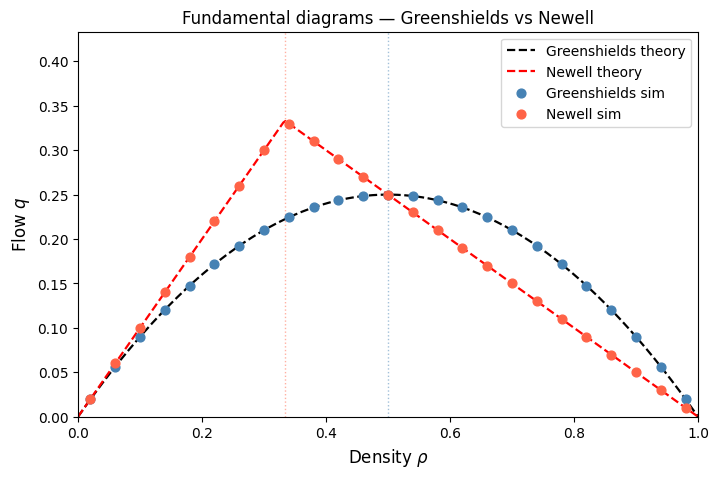

In [10]:
from pde_runner import q_newell as q_newell_func, rho_critical_newell

rho_theory = np.linspace(0.0, RHO_MAX, 300)
q_g_theory = q_of_rho(rho_theory, V_MAX, RHO_MAX)
q_n_theory = q_newell_func(rho_theory, V_MAX, RHO_MAX)

q_max_g = V_MAX * RHO_MAX / 4.0
rc_n    = rho_critical_newell(V_MAX, RHO_MAX)
q_max_n = V_MAX * rc_n

fig, ax = plt.subplots(figsize=(8, 5))

# Theoretical curves
ax.plot(rho_theory, q_g_theory, 'k--', linewidth=1.6, label='Greenshields theory')
ax.plot(rho_theory, q_n_theory, 'r--', linewidth=1.6, label='Newell theory')

# Simulation points
ax.scatter(rho_in, q_greenshields, s=40, color='steelblue', zorder=3, label='Greenshields sim')
ax.scatter(rho_in, q_newell,       s=40, color='tomato',    zorder=3, label='Newell sim')

# Critical points
ax.axvline(RC,   color='steelblue', linestyle=':', linewidth=1, alpha=0.5)
ax.axvline(rc_n, color='tomato',    linestyle=':', linewidth=1, alpha=0.5)

ax.set_xlabel('Density $\\rho$', fontsize=12)
ax.set_ylabel('Flow $q$', fontsize=12)
ax.set_xlim(0, RHO_MAX)
ax.set_ylim(0, max(q_max_g, q_max_n) * 1.3)
ax.set_title('Fundamental diagrams — Greenshields vs Newell', fontsize=12)
ax.legend(fontsize=10)

plt.show()

#### What you should see

The scatter points lie almost exactly on the theoretical curves, confirming the solver recovers both the parabolic Greenshields curve and the piecewise-linear Newell tent at steady state. The vertical dotted lines mark the critical densities — the throughput-maximising operating point for each model.


#### Try it yourself

1. **Increase $v_{\max}$:** setting `V_MAX = 2.0` doubles $q_{\max}$ from $0.25$ to $0.50$. The critical density $\rho_c = 0.5$ is unchanged — it depends only on $\rho_{\max}$.

2. **Coarser sweep:** `N_SWEEP = 10` still traces the parabola but the peak near $\rho_c$ is poorly resolved. Ten points is about the minimum to identify the closure.

3. **Shorter settling time:** a constant IC is already at steady state from $t=0$ — even `n_steps=50` gives $q_{\text{meas}} = q_{\text{theory}}$ exactly. To observe settling-time effects you would need a non-uniform IC.

4. **Resolution sensitivity:** all $M \in \{50, 100, 200, 400\}$ give $q = 0.25000$ exactly at $\rho = 0.5$ — the Godunov scheme is exact for a constant IC regardless of cell size.


---

## 4. Speed Limits

A speed limit $v_{\text{limit}}$ caps the free-flow velocity in the Greenshields closure:

$$v(\rho) = \min\!\left(v_{\max}\!\left(1 - \frac{\rho}{\rho_{\max}}\right),\ v_{\text{limit}}\right), \qquad q(\rho) = v(\rho)\,\rho$$

This creates a kink in the fundamental diagram at

$$\rho^* = \rho_{\max}\!\left(1 - \frac{v_{\text{limit}}}{v_{\max}}\right)$$

- For $\rho < \rho^*$: all vehicles travel at exactly $v_{\text{limit}}$ (the limit binds), so $q$ rises linearly with slope $v_{\text{limit}}$.
- For $\rho \geq \rho^*$: congestion is heavy enough that vehicles are already below the limit; $q$ follows the standard Greenshields concave branch.

When $\rho^* > \rho_c = \rho_{\max}/2$, the kink lies above the unconstrained peak and the maximum throughput is reduced to $q_{\max} = v_{\text{limit}}\,\rho^*$.

In [11]:
V_LIMITS = [0.4, 0.6, 0.8, 1.0]

sl_shock_data = []
for vl in V_LIMITS:
    nc = DATA_DIR / f'sl_shock_vl{int(vl * 10):02d}.nc'
    run_pde(
        dict(M=200, n_steps=500, ic_type='riemann', flux_type='godunov',
             bc_type='open', rho_left_bc=0.1, rho_right_bc=0.7, v_limit=vl),
        output_path=nc,
    )
    sl_shock_data.append((vl, load_pde_netcdf(nc)))

print('Speed limit shock runs complete.')

Speed limit shock runs complete.


#### Reading the figure

`plot_speed_limit_comparison` produces two sub-panels:

- **Left — fundamental diagram:** one curve per $v_{\text{limit}}$, colour-coded from dark (strictest) to bright (no limit). Vertical dotted lines mark $\rho^*$. For $v_{\text{limit}} < 0.5$, $\rho^* > \rho_c$ and the capacity peak is visibly clipped.
- **Right — final density profile:** $\rho(x)$ at $t_{\text{final}}$, one trace per $v_{\text{limit}}$. The shock has propagated for 500 steps; its position reveals the Rankine–Hugoniot speed $s = \Delta q / \Delta \rho$ under each flux curve.

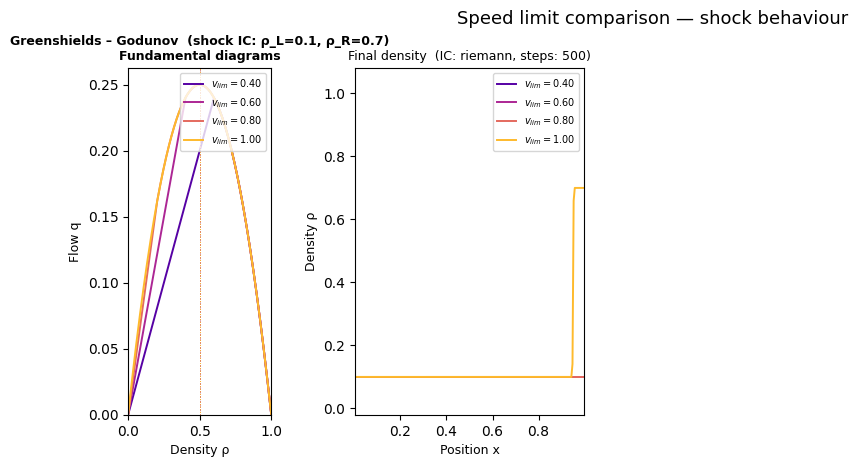

In [12]:
from pde_visualisation import plot_speed_limit_comparison

panel_datasets = [
    ("Greenshields – Godunov  (shock IC: ρ_L=0.1, ρ_R=0.7)", sl_shock_data),
]
fig = plot_speed_limit_comparison(panel_datasets)
plt.show()

#### What you should see

**Fundamental diagram:** The $v_{\text{limit}} = 1.0$ curve is the smooth Greenshields parabola. As the limit tightens, a kink appears and migrates rightward:

| $v_{\text{limit}}$ | $\rho^*$ | Capacity $q_{\max}$ |
|---------------------|-----------|----------------------|
| 1.0 | 0.00 | 0.25 (unchanged) |
| 0.8 | 0.20 | 0.25 (kink is below $\rho_c$, peak unaffected) |
| 0.6 | 0.40 | 0.25 (kink just below $\rho_c$, peak unaffected) |
| 0.4 | 0.60 | 0.24 (kink above $\rho_c$; 4 % reduction) |

**Final density profile:** The shock speed is $s = (q(\rho_R) - q(\rho_L))\,/\,(\rho_R - \rho_L)$. When $\rho^*$ falls between $\rho_L$ and $\rho_R$, the kink reduces $q(\rho_L)$ while $q(\rho_R)$ is unchanged, so $s$ increases — the shock advances further into the domain for a stricter limit:

| $v_{\text{limit}}$ | $s$ |
|---------------------|-----|
| 1.0 | 0.20 |
| 0.8 | 0.22 |
| 0.6 | 0.25 |
| 0.4 | 0.28 |

#### Try it yourself

1. **Capacity-reducing limit:** set `v_limit=0.3` (so $\rho^* = 0.70$, well above $\rho_c = 0.5$). The FD peak drops to $q_{\max} = 0.3 \times 0.7 = 0.21$ — a 16 % reduction — and the shock speed rises to $s \approx 0.32$.

2. **Rarefaction IC:** keep `v_limit=0.4` but change to `rho_left_bc=0.7`, `rho_right_bc=0.3`. Since $\rho^* = 0.6$ lies between the two states, all densities $\rho \in [0.3, 0.6]$ share the same characteristic speed $v_{\text{limit}} = 0.4$. The result is a compound wave: a smooth rarefaction fan from $\rho_L$ down to $\rho^*$, followed by a single contact discontinuity from $\rho^*$ to $\rho_R$ — visible in the space-time diagram as a fan with a sharp trailing edge.

3. **Newell closure with a limit:** change `flux_type='newell'`. The Newell FD is already piecewise-linear, so adding a speed limit clips its free-flow slope. Compare the resulting kinked shapes between the two closures.

---

## 5. Multilane LWR with Lane Changing

The single-lane LWR model treats all traffic as one stream. In reality drivers switch lanes to seek faster-moving traffic. The multilane extension adds one equation per lane and couples them with a source term:

$$\frac{\partial \rho_i}{\partial t} + \frac{\partial q_i(\rho_i)}{\partial x} = S_i, \qquad i = 1, \ldots, N_L$$

The lane-changing source term $S_i$ transfers density from lane $i$ to lane $j$ when lane $j$ is faster:

$$S_i = k \sum_{j \neq i} \Bigl(\rho_j\,[v_i(\rho_i) - v_j(\rho_j)]_+ - \rho_i\,[v_j(\rho_j) - v_i(\rho_i)]_+\Bigr)$$

where $[\cdot]_+ = \max(\cdot,\, 0)$ and $k$ is the lane-change rate. When all lanes travel at the same speed, $S_i = 0$ — no lane changing occurs. Total density is always conserved: $\sum_i S_i = 0$.


#### Scenario A vs B: independent and coupled lanes

Both scenarios start from the same staggered initial condition: lane 1 at $\rho = 0.7$ (congested, slow), lane 2 at $\rho = 0.2$ (free-flow, fast). Periodic boundary conditions enforce exact mass conservation.

| Parameter | Scenario A | Scenario B |
|-----------|-----------|-----------|
| `lane_change_rate` | 0.0 | 0.5 |
| `ic_type` | `'staggered'` | `'staggered'` |
| `bc_type` | `'periodic'` | `'periodic'` |

**Scenario A** ($k=0$): lanes are independent — no exchange, the initial contrast persists forever.  
**Scenario B** ($k=0.5$): the speed advantage of lane 2 drives vehicles out of the congested lane until their speeds equalise.


In [13]:
from pde_visualisation import plot_space_time_per_lane, plot_lane_densities, plot_total_mass

# Scenario A: independent lanes (k=0)
nc_A = DATA_DIR / 'ml_A_independent.nc'
run_pde(
    dict(n_lanes=2, lane_change_rate=0.0,
         v_max=V_MAX, rho_max=RHO_MAX,
         rho_left_bc=0.7, rho_right_bc=0.2,
         ic_type='staggered', flux_type='godunov', bc_type='periodic',
         M=200, n_steps=800),
    output_path=nc_A,
)
ml_A = load_pde_netcdf(nc_A)

# Scenario B: coupled lanes (k=0.5)
nc_B = DATA_DIR / 'ml_B_coupled.nc'
run_pde(
    dict(n_lanes=2, lane_change_rate=0.5,
         v_max=V_MAX, rho_max=RHO_MAX,
         rho_left_bc=0.7, rho_right_bc=0.2,
         ic_type='staggered', flux_type='godunov', bc_type='periodic',
         M=200, n_steps=800),
    output_path=nc_B,
)
ml_B = load_pde_netcdf(nc_B)

rho_A = ml_A['density_per_lane']  # shape: (time, lane, x)
rho_B = ml_B['density_per_lane']

print(f"A (k=0):   lane 1 final = {rho_A[-1,0,:].mean():.3f}   lane 2 = {rho_A[-1,1,:].mean():.3f}")
print(f"B (k=0.5): lane 1 final = {rho_B[-1,0,:].mean():.3f}   lane 2 = {rho_B[-1,1,:].mean():.3f}")
print(f"B total density conserved: {rho_B[-1,0,:].mean() + rho_B[-1,1,:].mean():.4f}  (started at {rho_A[0,0,:].mean()+rho_A[0,1,:].mean():.4f})")

A (k=0):   lane 1 final = 0.700   lane 2 = 0.200
B (k=0.5): lane 1 final = 0.511   lane 2 = 0.389
B total density conserved: 0.9000  (started at 0.9000)


#### Reading the figures

`plot_lane_densities` tracks the mean density of each lane over time at a fixed $x$-position, making the exchange clearly visible as two converging lines. In Scenario A the lines are flat; in Scenario B they converge toward $\rho_c = 0.45$.


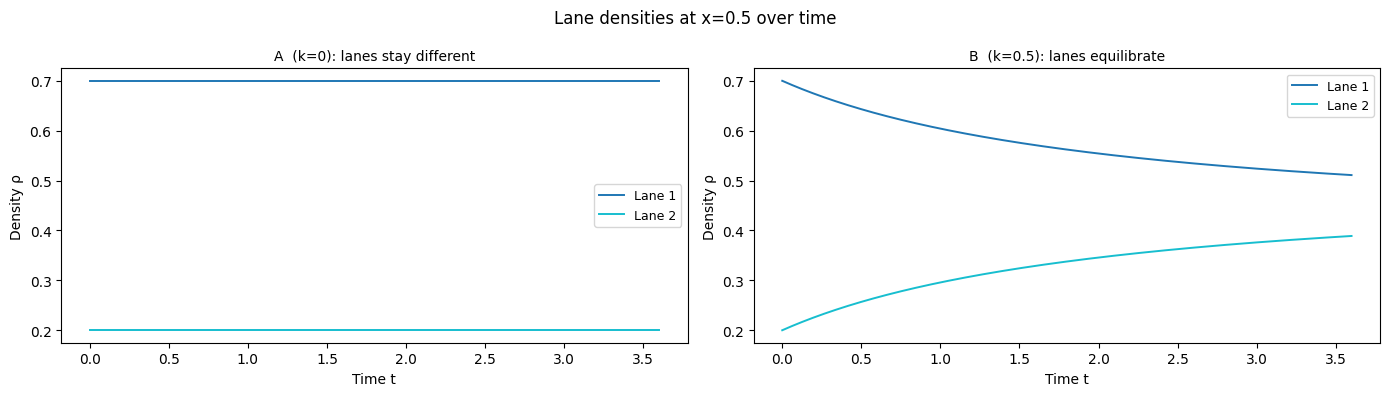

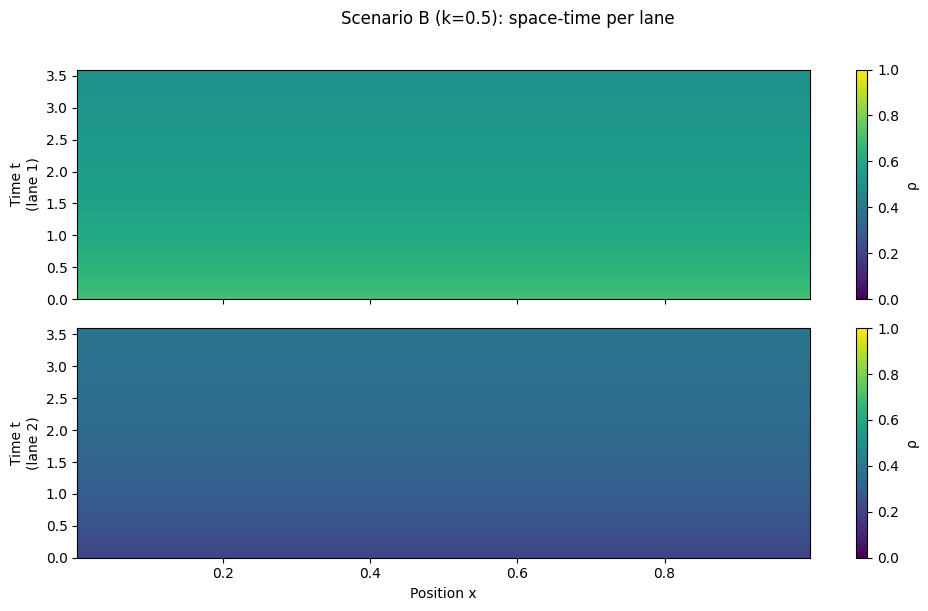

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_lane_densities(ml_A, x_pos=0.5, ax=axes[0])
axes[0].set_title('A  (k=0): lanes stay different', fontsize=10)

plot_lane_densities(ml_B, x_pos=0.5, ax=axes[1])
axes[1].set_title('B  (k=0.5): lanes equilibrate', fontsize=10)

fig.suptitle('Lane densities at x=0.5 over time', fontsize=12)
plt.tight_layout()
plt.show()

fig2, _ = plot_space_time_per_lane(ml_B, title='Scenario B (k=0.5): space-time per lane')
plt.show()

#### What you should see

**Scenario A (left):** two flat horizontal lines at $\rho_1=0.70$ and $\rho_2=0.20$ for all time. The lanes are completely decoupled — neither the flux nor the source term touches the other lane.

**Scenario B (right):** the lines converge. Lane 1 sheds density (vehicles leave the congested lane) and lane 2 gains it (vehicles join the faster lane). By $t \approx 3.6$ the lanes have moved from $(0.70, 0.20)$ to approximately $(0.51, 0.39)$ — not yet at equilibrium $0.45$ each, but clearly converging. Note that $0.51 + 0.39 = 0.90 = 0.70 + 0.20$: total density is exactly conserved.

**Space-time heatmaps (Scenario B):** lane 1 lightens uniformly over time (density falling), lane 2 darkens. The exchange is spatially uniform because the staggered IC has no spatial structure within each lane.


#### Scenario C: fast and slow lanes

This is the most physically striking case. Both lanes start at the same uniform density $\rho = 0.45$ but have different speed limits: lane 1 has $v_{\max}=1.0$, lane 2 has $v_{\max}=1.5$. Since both lanes start identical, the speed contrast arises purely from the different $v_{\max}$ values:

$$v_1(0.45) = 1.0 \times (1-0.45) = 0.55, \qquad v_2(0.45) = 1.5 \times (1-0.45) = 0.825$$

Lane 2 is faster, so vehicles migrate from lane 1 into lane 2. The equilibrium outcome is counterintuitive: the faster lane ends up denser.

In [15]:
nc_C = DATA_DIR / 'ml_C_fast_slow.nc'
run_pde(
    dict(n_lanes=2, lane_change_rate=0.5,
         v_max=V_MAX, rho_max=RHO_MAX,
         rho_left_bc=0.45, rho_right_bc=0.45,
         v_max_lanes=[1.0, 1.5],
         ic_type='constant', flux_type='godunov', bc_type='periodic',
         M=200, n_steps=1200),
    output_path=nc_C,
)
ml_C = load_pde_netcdf(nc_C)
rho_C = ml_C['density_per_lane']

rho1_eq = rho_C[-1, 0, :].mean()
rho2_eq = rho_C[-1, 1, :].mean()
v1_eq = V_MAX * (1 - rho1_eq / RHO_MAX)
v2_eq = 1.5  * (1 - rho2_eq / RHO_MAX)
print(f"Equilibrium: lane 1  ρ = {rho1_eq:.4f}   v = {v1_eq:.4f}")
print(f"Equilibrium: lane 2  ρ = {rho2_eq:.4f}   v = {v2_eq:.4f}")
print(f"Speed difference at equilibrium: {abs(v1_eq-v2_eq):.5f}")

Equilibrium: lane 1  ρ = 0.3687   v = 0.6313
Equilibrium: lane 2  ρ = 0.5313   v = 0.7031
Speed difference at equilibrium: 0.07176


#### Reading the figure

`plot_lane_densities` will show the two lanes diverging from the common starting point of $\rho=0.45$: lane 1 (slow) loses density, lane 2 (fast) gains it. The `plot_total_mass` panel should stay flat — a conservation check.


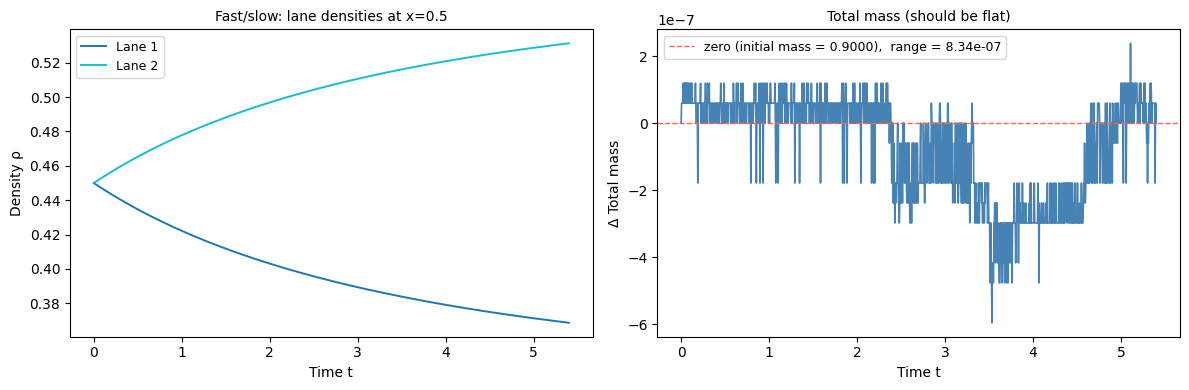

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_lane_densities(ml_C, x_pos=0.5, ax=axes[0])
axes[0].set_title('Fast/slow: lane densities at x=0.5', fontsize=10)
plot_total_mass(ml_C, ax=axes[1])
axes[1].set_title('Total mass (should be flat)', fontsize=10)
plt.tight_layout()
plt.show()

#### What you should see

Lane 2 (fast, $v_{\max}=1.5$) ends up denser ($\rho_2 \approx 0.53$) while lane 1 (slow, $v_{\max}=1.0$) ends up sparser ($\rho_1 \approx 0.37$). Why would the fast lane attract more vehicles?

Equilibrium is reached when speeds equalise, not densities. At equilibrium $v_1(\rho_1^*) = v_2(\rho_2^*)$:

$$v_{\max,1}\left(1 - \frac{\rho_1^*}{\rho_{\max}}\right) = v_{\max,2}\left(1 - \frac{\rho_2^*}{\rho_{\max}}\right)$$

Lane 2's higher speed limit means it can carry more vehicles while still matching lane 1's speed. Vehicles keep migrating until the speed advantage is fully absorbed by the added congestion. Total mass $\rho_1^* + \rho_2^* = 0.90$ is conserved exactly.

In traffic terms: a motorway fast lane will be more densely occupied at equilibrium — it attracts drivers until its congestion exactly cancels its speed advantage.


#### Try it yourself

1. **Lane-change rate sensitivity:** run Scenario B with $k \in \{0.1, 0.5, 1.0, 2.0\}$. The residual imbalance $|\rho_1 - \rho_2|$ at $t_{\text{final}}$ is $0.349$, $0.122$, $0.043$, $0.007$ respectively — higher $k$ gives faster equilibration, but the equilibrium density of $0.45$ is independent of $k$.

2. **No lane changing, asymmetric $v_{\max}$:** run Scenario C with `lane_change_rate=0.0`. Both lanes stay exactly at $\rho=0.45$ — without lane changing, a speed differential causes no redistribution at all.

3. **Symmetric IC, nonzero $k$:** start both lanes at `rho=0.45` with equal $v_{\max}$ and `lane_change_rate=0.5`. Since the speed differential is zero everywhere, $S_i = 0$ identically and both lanes stay at $\rho=0.45$.

4. **Three lanes:** set `n_lanes=3` with `v_max_lanes=[1.0, 1.2, 1.5]` and a staggered IC. Predict which lane ends up densest before running.


# Cellular Automata Traffic Flow — Tutorial


## Background

Cellular automaton (CA) models take a different approach to traffic flow from the LWR PDE. Instead of treating traffic as a continuous fluid, they represent individual vehicles as discrete particles on a lattice, updated in parallel at each integer time step.

### The TASEP model

The **Totally Asymmetric Simple Exclusion Process** (TASEP) is the simplest CA traffic model. The road is divided into $L$ sites, each either occupied ($1$) or empty ($0$). At every time step, all sites are updated simultaneously in this order:

1. **Exit:** if final site, $L$, is occupied, the vehicle leaves with probability $\beta$.
2. **Bulk hop:** every vehicle at site $i < L$ moves to site $i+1$ if that site is empty.
3. **Entry:** if initial site, $1$, is empty after the hop step, a new vehicle enters with probability $\alpha$.

The parameters $\alpha \in [0,1]$ (inflow rate) and $\beta \in [0,1]$ (outflow rate) control the boundaries.

### Phase diagram

In the infinite-$L$ limit the TASEP has three exact steady states, depending on $\alpha$ and $\beta$:

| Phase | Condition | Bulk density $\rho$ | Flow $J$ |
|-------|-----------|---------------------|----------|
| Low Density (LD) | $\alpha < \beta$,\ $\alpha < \tfrac{1}{2}$ | $\alpha$ | $\alpha(1-\alpha)$ |
| High Density (HD) | $\beta < \alpha$,\ $\beta < \tfrac{1}{2}$ | $1-\beta$ | $\beta(1-\beta)$ |
| Maximum Current (MC) | $\alpha > \tfrac{1}{2}$,\ $\beta > \tfrac{1}{2}$ | $\tfrac{1}{2}$ | $\tfrac{1}{4}$ |

In every phase $J = \rho(1-\rho)$ — the **fundamental diagram is a parabola**, identical in shape to the Greenshields LWR closure.

### The Nagel–Schreckenberg model

The **NS model** extends TASEP by giving each vehicle an integer velocity $v \in \{0,1,\ldots,v_{\max}\}$. Each step applies four sub-rules in order:

1. **Accelerate:** $v \leftarrow \min(v+1,\, v_{\max})$
2. **Brake:** $v \leftarrow \min(v,\, d-1)$, where $d$ is the gap to the next vehicle
3. **Randomise:** with probability $p_{\text{slow}}$, $v \leftarrow \max(v-1, 0)$
4. **Move:** vehicle advances $v$ sites

The stochastic braking ($p_{\text{slow}}>0$) destabilises uniform flow and produces **phantom jams** — backward-propagating stop-and-go waves that arise spontaneously without any bottleneck.

### What you will see

1. **TASEP — three phases:** space-time diagrams for LD, MC, and HD, and the fundamental diagram parabola recovered by a parameter sweep.
2. **NS — phantom jams:** a periodic ring at $\rho=0.20$ spontaneously develops backward-travelling jam waves.
3. **Lane changing:** a two-lane road simulated with and without the lane-change module.
4. **Full network:** a T-junction simulation using the Fortran network binary (`./build/run_network`).

In [17]:
import sys
sys.path.insert(0, str(ROOT / 'src'))   # needed for python.* package imports inside run_simulation

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# CA fundamental-diagram sweeps now run in Fortran via build/fd_sweep; the
# Python wrapper lives in python.fd_runner. The three-phase TASEP demo and
# the phantom-jam periodic-NS demo both drive the same Fortran network
# simulator (build/run_network) via run_simulation, and read the resulting
# NetCDF back with python.io.load_network_netcdf. The previous pure-Python
# tasep_step / ns_step_periodic kernels were removed from analysis.py
# because they duplicated the Fortran update routines.
from python.fd_runner import run_fd_sweep, load_fd_netcdf
from CA_visualisation import (
    plot_spacetime, plot_density, plot_current, plot_fundamental_diagram,
    plot_network_layout, plot_network_density, plot_network_currents,
    plot_network_spacetime,
)
from python.road_network import single_lane, single_lane_periodic, two_lane, t_junction, SimParams
from python.io import load_network_netcdf
from run_simulation import run_simulation

BINARY = ROOT / 'build' / 'run_network'
print('CA setup complete.')

CA setup complete.


---
## 1. The TASEP Model

The TASEP is the minimal open-boundary lattice gas. Its three parallel-update rules (exit, hop, entry) produce three macroscopically distinct steady states — low density, maximum current, and high density — all lying on the same triangular fundamental diagram $J = \min(\rho,\, 1-\rho)$ (with deterministic-bulk parallel update and stochastic α/β boundaries).

The three demos below show one representative from each phase on a lattice of $L = 100$ sites, all driven by the Fortran network simulator.

### Imports and setup

The cell above imports four local modules:

- **`python.fd_runner`** — thin Python wrapper around the compiled Fortran fundamental-diagram driver `build/fd_sweep` (open-boundary TASEP α/β sweep, periodic-ring NS density sweep).
- **`CA_visualisation`** — plotting helpers: `plot_spacetime`, `plot_density`, `plot_current`, `plot_fundamental_diagram` for 1D results; `plot_network_*` for full-network results.
- **`run_simulation`** — Python wrapper around `./build/run_network` (the compiled Fortran network simulator). Drives the three-phase TASEP demo by running a single-lane network per phase and reading the resulting NetCDF.
- **`python.io.load_network_netcdf`** — reads the NetCDF produced by `run_network` back into a `NetworkResult` dataclass with `occupancy`, `road_density`, `road_exits` etc.

#### Parameters

| Parameter | Value | Reason |
|-----------|-------|--------|
| `L` | 100 | Long enough for a clear bulk region; boundary layers confined to $\sim\!\sqrt{L}$ sites |
| `N_STEPS` | 800 | Covers several domain-wall transit times in all three phases |
| Free-flow: $\alpha=0.2$, $\beta=0.8$ | LD phase | $\alpha < \beta$, $\alpha < \tfrac{1}{2}$ → $\rho\approx0.30$, $J\approx0.21$ |
| Max current: $\alpha=0.8$, $\beta=0.8$ | MC phase | both $>\tfrac{1}{2}$ → $\rho\approx0.50$, $J\approx0.44$ |
| Traffic jam: $\alpha=0.8$, $\beta=0.2$ | HD phase | $\beta < \alpha$, $\beta < \tfrac{1}{2}$ → $\rho\approx0.80$, $J\approx0.16$ |

Free flow (LD)        α=0.2  β=0.8  ρ_theory=0.20  J_theory=0.2000  ρ_meas=0.180  J_meas=0.1775
Max current (MC)      α=0.8  β=0.8  ρ_theory=0.50  J_theory=0.5000  ρ_meas=0.487  J_meas=0.4350
Traffic jam (HD)      α=0.8  β=0.2  ρ_theory=0.80  J_theory=0.2000  ρ_meas=0.826  J_meas=0.1825


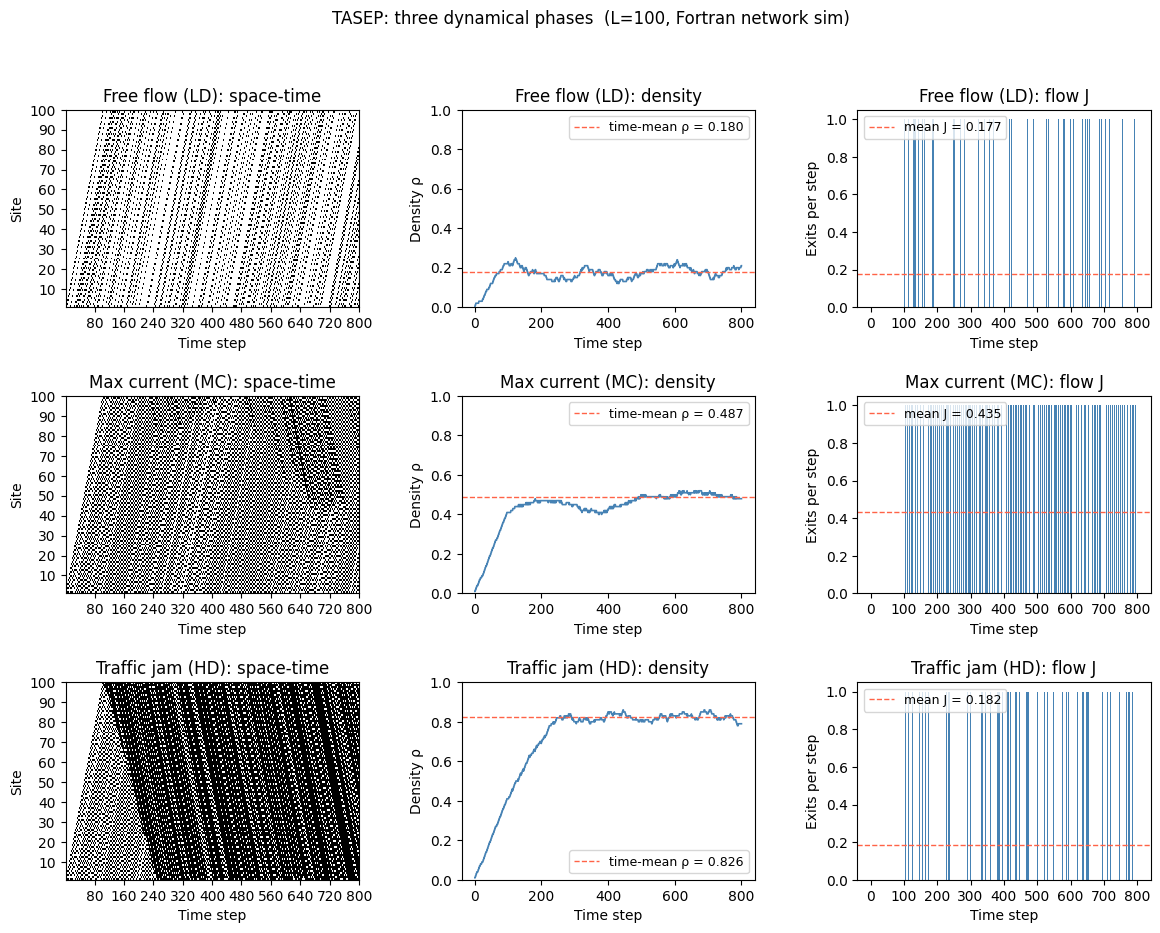

In [18]:
L, N_STEPS = 100, 800
CONFIGS = [
    ('Free flow (LD)',    0.2, 0.8),
    ('Max current (MC)', 0.8, 0.8),
    ('Traffic jam (HD)', 0.8, 0.2),
]

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(3, 3, hspace=0.45, wspace=0.35)

for row, (label, alpha, beta) in enumerate(CONFIGS):
    # One run of the Fortran network simulator per phase, single_lane preset.
    spec, layout = single_lane(L=L, alpha=alpha, beta=beta)
    params = SimParams(n_steps=N_STEPS, model='TASEP', v_max=1, p_slow=0.0,
                       rng_seed=42)
    nc_path = run_simulation(spec, params, layout,
                             DATA_DIR / f'tutorial_tasep_{label[:2].lower()}',
                             BINARY)
    result = load_network_netcdf(nc_path)

    # Pack the NetworkResult into the shape plot_spacetime/density/current
    # expect: history shape (cell, time); density/current shape (time,).
    data = dict(
        L=L, n_steps=N_STEPS, alpha=alpha, beta=beta,
        history=result.occupancy[:, 0, :L].T,
        density=result.road_density[:, 0],
        current=result.road_exits[:, 0],
    )

    plot_spacetime(data, ax=fig.add_subplot(gs[row, 0]), title=f'{label}: space-time')
    plot_density  (data, ax=fig.add_subplot(gs[row, 1]), title=f'{label}: density')
    plot_current  (data, ax=fig.add_subplot(gs[row, 2]), title=f'{label}: flow J')

    rho_theory = alpha if alpha < 0.5 else (0.5 if beta > 0.5 else 1 - beta)
    J_theory   = min(rho_theory, 1 - rho_theory)
    print(f'{label:20s}  α={alpha}  β={beta}  '
          f'ρ_theory={rho_theory:.2f}  J_theory={J_theory:.4f}  '
          f'ρ_meas={data["density"][-400:].mean():.3f}  '
          f'J_meas={data["current"][-400:].mean():.4f}')

fig.suptitle('TASEP: three dynamical phases  (L=100, Fortran network sim)', fontsize=12)
plt.show()

#### Reading the figure

Three columns are produced:

- **Left — space-time diagram:** each column of pixels is a snapshot of all $L$ sites; black = occupied, white = empty; time runs left to right. Diagonal streaks slanting from bottom-left to top-right are vehicles moving freely. Diagonal in the oppposite direction are jams — vehicles that are not moving.
- **Middle — density vs time:** mean occupancy $\rho(t)=N(t)/L$ over all sites. The red dashed line is the time-mean; compare it against the theoretical $\rho$ for each phase.
- **Right — flow vs time:** number of exits (particles leaving site $L$) per step. Higher line density indicates a greater current. The red dashed line is the mean $\bar{J}$.

#### What you should see

**Row 1 — Free flow (LD, $\alpha=0.2$, $\beta=0.8$):** sparse, right-leaning diagonal streaks (vehicles traversing the lattice freely). The density panel settles near $\rho\approx0.18\approx\alpha$ and the flow panel near $J\approx0.17\approx\alpha(1-\alpha)$. The inflow is the bottleneck — the lattice cannot fill faster than vehicles enter.

**Row 2 — Maximum current (MC, $\alpha=\beta=0.8$):** busy and fluctuating, with domain walls (sharp density boundaries) diffusing across the lattice. Mean density $\rho\approx0.50$ and mean flow $J\approx0.44$ — nearing the maximum possible. Neither boundary is the bottleneck; the bulk itself is saturated. The current would be maximised at $\alpha=\beta=1.0$.

**Row 3 — Traffic jam (HD, $\alpha=0.8$, $\beta=0.2$):** densely occupied with only occasional gaps. Left-leaning dark diagonals indicate presence of traffic jams. Mean density $\rho\approx0.80\approx1-\beta$ and flow $J\approx0.16\approx\beta(1-\beta)$. The outflow is the bottleneck — vehicles accumulate faster than they can leave.

#### Try it yourself

1. **Near-critical states:** set $\alpha=0.48$, $\beta=0.52$. The system is deep in the LD phase but very close to the MC boundary; the domain wall diffuses slowly and density fluctuates strongly. Increase `N_STEPS` to 2000 to see the long-time behaviour.

2. **Symmetric boundaries:** set $\alpha=\beta$ and sweep the common value from 0.1 to 0.9. For $\alpha=\beta<\tfrac{1}{2}$ the system sits on the LD/HD coexistence line — the domain wall performs a random walk, spending equal time near both ends. For $\alpha=\beta>\tfrac{1}{2}$ it is in the MC phase.

3. **Finite-size effects:** compare `L=20` with `L=200` at the same $(\alpha,\beta)$. The smaller lattice shows larger density fluctuations and the measured $\rho$ deviates more from the infinite-$L$ mean-field prediction.

4. **Deterministic limit:** set $\alpha=1$, $\beta=1$. With no randomness the update rule is fully deterministic; after a short transient the system locks into a periodic pattern and the space-time diagram becomes almost perfectly regular.

Peak J = 0.4950  at  ρ = 0.505
Theory: peak J = 0.50 at ρ = 0.50  (deterministic-bulk parallel TASEP)


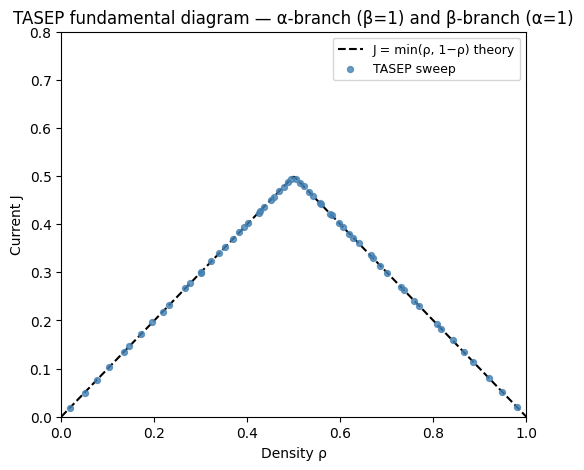

In [19]:
nc_path = run_fd_sweep(model='TASEP', L=50, n_points=30, n_steps=3000, seed=42,
                       output_path=DATA_DIR / 'tutorial_fd_tasep.nc')
fd = load_fd_netcdf(nc_path)
rho, J = fd['rho'], fd['J']
print(f'Peak J = {J.max():.4f}  at  ρ = {rho[J.argmax()]:.3f}')
print(f'Theory: peak J = 0.50 at ρ = 0.50  (deterministic-bulk parallel TASEP)')

fig, ax = plot_fundamental_diagram(rho, J, model='TASEP')
ax.set_title('TASEP fundamental diagram — α-branch (β=1) and β-branch (α=1)')
plt.show()

#### Fundamental diagram

The sweep traces the full $J(\rho)$ curve along two deterministic-boundary cuts: $\alpha$ varies from 0.02 to 0.98 with $\beta=1$ (LD branch up to the max-current point), then $\beta$ varies from 0.02 to 0.98 with $\alpha=1$ (HD branch back to the same point). Holding the fixed boundary at 1 makes that side a noise-free reservoir, so the bulk recovers the textbook $J = \min(\rho,\, 1-\rho)$ shape — two straight lines meeting at $(\rho, J) = (0.5,\, 0.5)$. This peak occurs at $\alpha=\beta=1.0$. The two branches together cover $\rho \in [0.02, 0.98]$ without a gap at the max-current point.

---
## 2. Nagel–Schreckenberg Model

The NS model extends TASEP by giving each vehicle an integer velocity $v \in \{0,1,\ldots,v_{\max}\}$. Its four update rules model human driving behaviour more realistically:

| Step | Rule |
|------|------|
| **Accelerate** | $v \leftarrow \min(v+1,\ v_{\max})$ |
| **Brake** | $v \leftarrow \min(v,\ d-1)$, where $d$ = gap to next vehicle |
| **Randomise** | with prob $p_{\text{slow}}$: $v \leftarrow \max(v-1, 0)$ |
| **Move** | vehicle advances $v$ sites |

**Key difference from TASEP:** even at low densities ($\rho \ll 1$), if $p_{\text{slow}}>0$ a single random braking event can nucleate a backward-propagating jam — a *phantom jam* that moves upstream at roughly one site per step without any bottleneck causing it.

Here, the NS model runs on a **periodic ring** (no entry/exit) , so the total vehicle count and density $\rho=N/L$ are fixed. The stability boundary is approximately $\rho_c \approx 1/(v_{\max}+1)$: below this density uniform flow is stable; above it phantom jams form spontaneously.

[NOTE: Periodic roads are currently not usable through the GUI, so must be used through the Python API]

#### Parameters

| Parameter | Value | Reason |
|-----------|-------|--------|
| `L` | 200 | Large ring; jams can propagate $\approx 20$ sites/step before wrapping |
| `N_VEHICLES` | 40 | $\rho=0.20$; above $\rho_c\approx1/6\approx0.17$ — in the jam-forming regime |
| `v_max` | 5 | Corresponds to $\approx120\,\text{km/h}$ (1 cell $\approx$ 7.5 m, 1 step $\approx$ 1 s) |
| `p_slow` | 0.3 | Strong enough to trigger phantom jams reliably within 300 burn-in steps |
| Burn-in | 300 | Discards the start-up transient before recording the space-time diagram |

Measured density: ρ = 0.2000  (target: 0.2000)


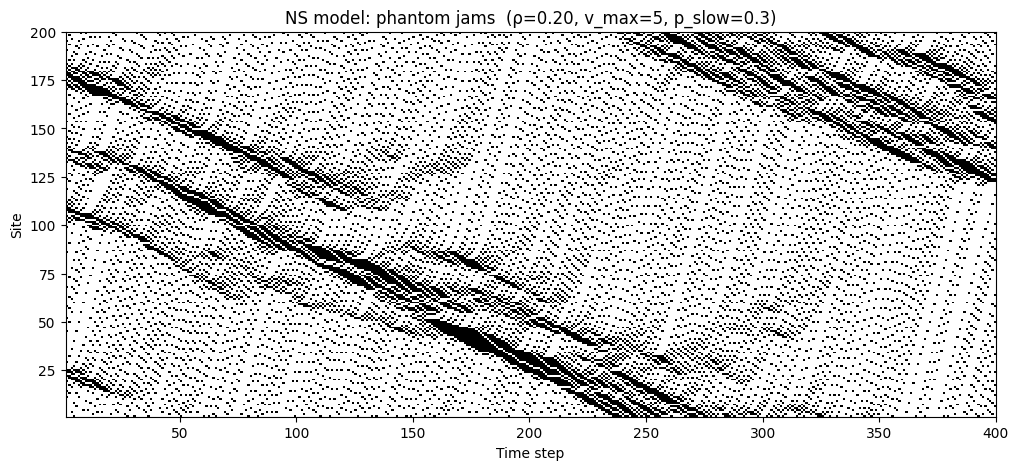

In [20]:
L, N_STEPS  = 200, 400
N_VEHICLES  = 40          # density = N_VEHICLES / L = 0.20
V_MAX       = 5
P_SLOW      = 0.3
BURNIN      = 300         # discard transient before recording history

# single_lane_periodic builds a one-road, one-lane spec with the lane flagged
# as a closed ring and pre-seeded with N_VEHICLES cars at evenly-spaced
# sites. The Fortran network simulator handles the periodic NS step natively
# (NS_model_step's is_periodic branch), so we just run one sim of length
# BURNIN + N_STEPS, discard the transient, and read back the cell-by-time
# occupancy from the NetCDF.
spec, layout = single_lane_periodic(L=L, n_vehicles=N_VEHICLES)
params = SimParams(n_steps=BURNIN + N_STEPS, model='NS',
                   v_max=V_MAX, p_slow=P_SLOW, rng_seed=42)
result = load_network_netcdf(run_simulation(spec, params, layout,
                                            DATA_DIR / 'tutorial_phantom_jam',
                                            BINARY))

# occupancy shape is (time, lane, cell); single_lane_periodic has one lane,
# so [:, 0, :L]. Transpose to (cell, time) for imshow with rows=site.
history_ns = result.occupancy[BURNIN:, 0, :L].T.astype(np.int8)

print(f'Measured density: ρ = {history_ns.mean():.4f}  (target: {N_VEHICLES/L:.4f})')

fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(history_ns, aspect='auto', origin='lower', cmap='binary',
          interpolation='nearest', extent=[1, N_STEPS, 1, L])
ax.set_xlabel('Time step')
ax.set_ylabel('Site')
ax.set_title(
    f'NS model: phantom jams  '
    f'(ρ={N_VEHICLES/L:.2f}, v_max={V_MAX}, p_slow={P_SLOW})'
)
plt.show()

#### Reading the figure

The space-time diagram shows the 200-site ring over 300 steps. Dark cells are occupied. Look for:

- **Left-slanting dark bands:** these are jam waves propagating backward (upstream). Vehicles entering the back of a jam from the right arrive quickly; vehicles leaving the front on the left accelerate slowly.
- **Right-slanting clear bands:** free-flow regions between jams, where vehicles travel at $v\approx v_{\max}$.

The jams are not caused by any external obstacle (as the road is periodc) — they arise entirely from the stochastic braking rule and the finite reaction distance encoded in the brake-to-gap step.

#### What you should see

With $\rho=0.20>\rho_c\approx0.17$ and $p_{\text{slow}}=0.3$, the flow is unstable. After burn-in you should see 3–5 jam waves propagating diagonally to the **left** in the space-time diagram. Each jam is roughly 10–20 sites wide and travels at $\approx-1$ site/step.

Between jams, vehicles move freely at $v\approx v_{\max}=5$ (visible as right-slanting free-flow bands). The pattern is self-sustaining: a vehicle brakes randomly, forcing the one behind to brake hard (zero gap), and the disturbance propagates backward indefinitely.

The jams are periodic on the ring — they cycle around, occasionally merging when a faster jam catches a slower one.

Computing TASEP fundamental diagram (L=50, n_points=25)...
Computing NS fundamental diagram (L=100, v_max=5, p_slow=0.2, n_points=25)...
TASEP peak J = 0.4950  at  ρ = 0.505
NS    peak J = 0.6162  at  ρ = 0.140
NS ρ_c ≈ 1/(v_max+1) = 0.1667


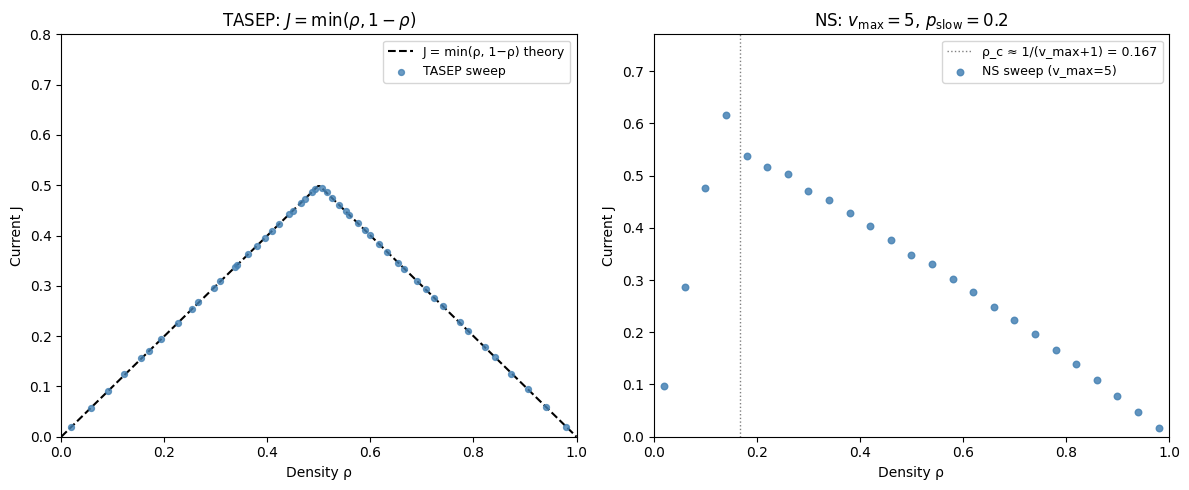

In [21]:
print('Computing TASEP fundamental diagram (L=50, n_points=25)...')
fd_t = load_fd_netcdf(run_fd_sweep(
    model='TASEP', L=50, n_points=25, n_steps=3000, seed=42,
    output_path=DATA_DIR / 'tutorial_fd_tasep_compare.nc',
))
rho_tasep, J_tasep = fd_t['rho'], fd_t['J']

print('Computing NS fundamental diagram (L=100, v_max=5, p_slow=0.2, n_points=25)...')
fd_n = load_fd_netcdf(run_fd_sweep(
    model='NS', L=100, n_points=25, n_steps=1500, v_max=5, p_slow=0.2,
    seed=42, output_path=DATA_DIR / 'tutorial_fd_ns_compare.nc',
))
rho_ns, J_ns = fd_n['rho'], fd_n['J']

rho_c_ns = 1.0 / (5 + 1)
print(f'TASEP peak J = {J_tasep.max():.4f}  at  ρ = {rho_tasep[J_tasep.argmax()]:.3f}')
print(f'NS    peak J = {J_ns.max():.4f}  at  ρ = {rho_ns[J_ns.argmax()]:.3f}')
print(f'NS ρ_c ≈ 1/(v_max+1) = {rho_c_ns:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_fundamental_diagram(rho_tasep, J_tasep, ax=axes[0], model='TASEP')
axes[0].set_title(r'TASEP: $J = \min(ρ, 1-ρ)$')
plot_fundamental_diagram(rho_ns, J_ns, ax=axes[1], model='NS', v_max=5)
axes[1].set_title(r'NS: $v_{\max}=5$, $p_{\mathrm{slow}}=0.2$')
plt.tight_layout()
plt.show()


#### Fundamental diagram comparison

The TASEP diagram (left) is two straight lines meeting at $(\rho, J) = (0.5,\, 0.5)$: $J = \rho$ on the LD branch, $J = 1-\rho$ on the HD branch. That is the textbook fundamental diagram for deterministic-bulk parallel-update TASEP — the bulk fits an alternating "X O X O" pattern in which every car can hop every step at $\rho = 0.5$, so $J_{\max} = 0.5$.

The NS diagram (right) has a very different shape:
- **Free-flow branch** ($\rho<\rho_c$): roughly linear rise — each additional vehicle contributes $\approx v_{\max}$ moves per step.
- **Congested branch** ($\rho>\rho_c$): near-linear fall as jam waves dominate throughput.
- **Critical density** $\rho_c\approx1/(v_{\max}+1)=1/6$ is where spontaneous jams first appear.

Higher $v_{\max}$ raises peak flow and shifts the peak left to a lower critical density.

#### Try it yourself

1. **Remove randomisation:** set `P_SLOW = 0.0`. Without stochasticity, uniform flow is linearly stable at any density — no phantom jams form and the space-time diagram shows clean diagonal stripes. The fundamental diagram (below) becomes a triangle with a sharp kink at $\rho_c$.

2. **Match TASEP:** set `V_MAX = 1`. With $v_{\max}=1$ the NS model is a close relative of TASEP (periodic ring instead of open boundaries); $\rho_c = 1/(1+1) = 0.5$, recovering the TASEP symmetry point.

3. **Right at the stability boundary:** set `N_VEHICLES = 34` ($\rho\approx0.17\approx\rho_c$). Jams form and dissolve intermittently; the space-time diagram shows intermittent jam nucleation rather than the persistent waves seen above.

4. **Large ring:** try `L = 500`, `N_VEHICLES = 100` (same $\rho=0.2$). Multiple independent jam waves coexist; count them — the number scales with $L$.

---
## 3. Lane Changing

Real motorways have multiple lanes, and drivers switch to avoid slower vehicles. The lane-change module (`lane_change.f90`) applies a sub-step before each NS step, checking four conditions for every vehicle:

| Condition | Description |
|-----------|-------------|
| **T1** — blocked | Gap ahead in current lane $< v+1$ (cannot reach full speed) |
| **T2** — target ahead clear | Gap ahead in target lane $> v+1$ |
| **T3** — target behind clear | Gap behind in target lane $> v_{\max}$ |
| **T4** — random acceptance | Uniform draw $< p_{\text{change}}$ |

A lane change occurs only when all four conditions are satisfied simultaneously. Two models are available:

- **Symmetric** (`lc_model=0`): any lane can be the target; T1 is required for all moves.
- **Asymmetric** (`lc_model=1`): vehicles prefer the rightmost (lowest-index) lane; returning right does not require T1.


#### Parameters

| Parameter | Value | Reason |
|-----------|-------|--------|
| `L` | 50 | Long enough for bulk lane-change dynamics to develop |
| `alpha`, `beta` | 0.5 | Moderate, symmetric boundaries; neither end dominates |
| `n_steps` | 500 | Sufficient for steady-state statistics |
| model | `'NS'` | $v_{\max}=5$, $p_{\text{slow}}=0.2$ — TASEP does not support multi-lane geometry |
| No lane-changing | `lc_model=-1` | Lanes are fully independent |
| Symmetric lane-changing | `lc_model=0`, `lc_p_change=1.0` | Accept every valid opportunity |

In [22]:
spec, layout = two_lane(L=50, alpha=0.5, beta=0.5)

params_off = SimParams(n_steps=500, model='NS', v_max=5, p_slow=0.2,
                       lc_model=-1, rng_seed=42)
params_on  = SimParams(n_steps=500, model='NS', v_max=5, p_slow=0.2,
                       lc_model=0, lc_p_change=1.0, rng_seed=42)

nc_off = run_simulation(spec, params_off, layout, DATA_DIR / 'lc_off', BINARY)
nc_on  = run_simulation(spec, params_on,  layout, DATA_DIR / 'lc_on',  BINARY)

result_off = load_network_netcdf(nc_off)
result_on  = load_network_netcdf(nc_on)

for label, result in [('No LC  (lc_model=-1)', result_off),
                       ('Sym LC (lc_model= 0)', result_on)]:
    rho = result.road_density[:, 0].mean()
    J   = result.road_exits[:, 0].mean()
    print(f'{label}: mean ρ = {rho:.3f},  mean exits/step = {J:.2f}')

No LC  (lc_model=-1): mean ρ = 0.188,  mean exits/step = 0.57
Sym LC (lc_model= 0): mean ρ = 0.114,  mean exits/step = 0.58


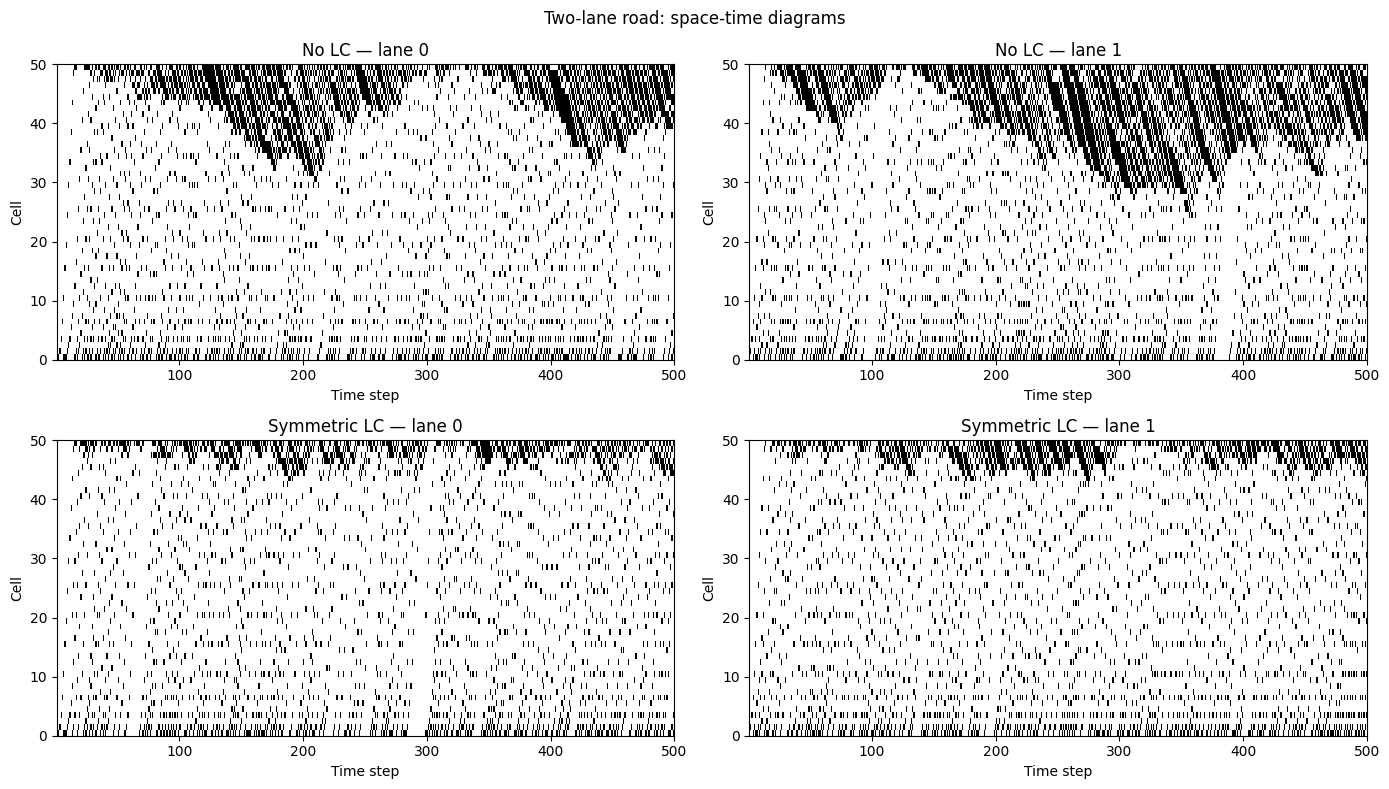

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_network_spacetime(result_off, road_id=1, ax=axes[0, 0], lane_index=0,
                       title='No LC — lane 0')
plot_network_spacetime(result_off, road_id=1, ax=axes[0, 1], lane_index=1,
                       title='No LC — lane 1')
plot_network_spacetime(result_on,  road_id=1, ax=axes[1, 0], lane_index=0,
                       title='Symmetric LC — lane 0')
plot_network_spacetime(result_on,  road_id=1, ax=axes[1, 1], lane_index=1,
                       title='Symmetric LC — lane 1')

fig.suptitle('Two-lane road: space-time diagrams', fontsize=12)
plt.tight_layout()
plt.show()

#### Reading the figure

Four panels show the space-time diagram of each lane for both configurations (rows = LC off/on, columns = lane 0/lane 1). Black = occupied, site on $y$-axis, time on $x$-axis.

**Without LC (top row):** the two lanes are statistically independent — jam patterns in lane 0 and lane 1 are uncorrelated, driven only by the same shared $\alpha$ and $\beta$.

**With symmetric LC (bottom row):** the lanes are correlated. When a jam appears in lane 0 (dark patch), vehicles switch to lane 1, reducing the jam density in lane 0 while producing a transient shadow in lane 1. Jams are shorter-lived and the density distribution is smoother.

#### What you should see

With symmetric lane changing enabled, vehicles escape jammed lanes by switching, which tends to:

- **Reduce peak jam density** in either lane — jams dissolve faster because blocked vehicles find a lateral escape route.
- **Correlate the two lanes** — a dense patch in lane 0 produces a corresponding shadow in lane 1, as vehicles simultaneously leave the jammed lane and transiently occupy the clear one.
- **Slightly increase mean throughput** — because fewer vehicles are stuck waiting for a gap that a lane change would avoid, the mean exits per step with LC enabled should be marginally higher.

The asymmetric model (`lc_model=1`) additionally pulls vehicles back to the rightmost lane once they are no longer blocked, so at equilibrium lane 0 is denser and lane 1 is sparser — a motorway-style "keep right" convention.

---
## 4. Full Network Simulation

The Fortran binary supports arbitrary road networks: multiple roads connected at junctions, each with a routing probability table specifying where vehicles go when they exit a road, and right-of-way rules to resolve conflicts at each junction.

**T-junction preset** (`t_junction`): three roads — W arm, E arm, and S stem — meet at a single junction.

$$\text{Routing from W:} \quad \underbrace{p_{\text{through}}}_{\to\text{E}} + \underbrace{(1-p_{\text{through}})}_{\to\text{S}} = 1 \qquad \text{Routing from S: 50\% W, 50\% E}$$

Each road has two lanes: one inbound (carrying vehicles toward the junction) and one outbound (carrying vehicles away). The boundary ends are open with inflow rate $\alpha$ and outflow rate $\beta$.


#### Parameters

| Parameter | Value | Reason |
|-----------|-------|--------|
| `L` | 30 cells per arm | Long enough for internal density gradients to form near the junction |
| `alpha` | 0.4 | Moderate inflow — avoids saturation while producing visible traffic |
| `beta` | 0.5 | Slightly higher than $\alpha$; the junction is not the hard bottleneck |
| `p_through` | 0.6 | 60% of W↔E traffic continues straight; 40% diverts to the stem |
| `n_steps` | 1000 | Enough for the density transient to settle to quasi-steady state |
| model | `'NS'` | More realistic driver behvaiour, $v_{\max}=5$, $p_{\text{slow}}=0.2$ |

In [24]:
from python.road_network import t_junction

spec, layout = t_junction(L=30, alpha=0.4, beta=0.6, p_through=0.6)
params = SimParams(n_steps=1000, model='NS', v_max=5, p_slow=0.2, rng_seed=42)

nc_net = run_simulation(spec, params, layout, DATA_DIR / 'tutorial_tjunction', BINARY)
result = load_network_netcdf(nc_net)

print(f'Simulation complete.  Roads: {[r.id for r in spec.roads]}')
for i, road in enumerate(spec.roads):
    rho     = result.road_density[:, i].mean()
    entries = int(result.road_entries[:, i].sum())
    exits   = int(result.road_exits[:,   i].sum())
    print(f'  Road {road.id}: mean ρ = {rho:.3f}  '
          f'total entries = {entries:5d}  exits = {exits:5d}')

Simulation complete.  Roads: [1, 2, 3]
  Road 1: mean ρ = 0.160  total entries =   269  exits =   293
  Road 2: mean ρ = 0.125  total entries =   271  exits =   274
  Road 3: mean ρ = 0.105  total entries =   274  exits =   217


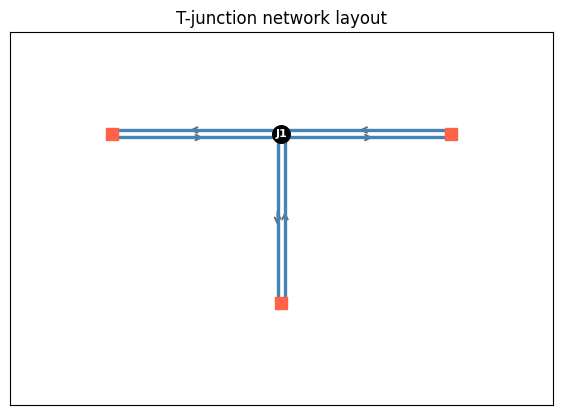

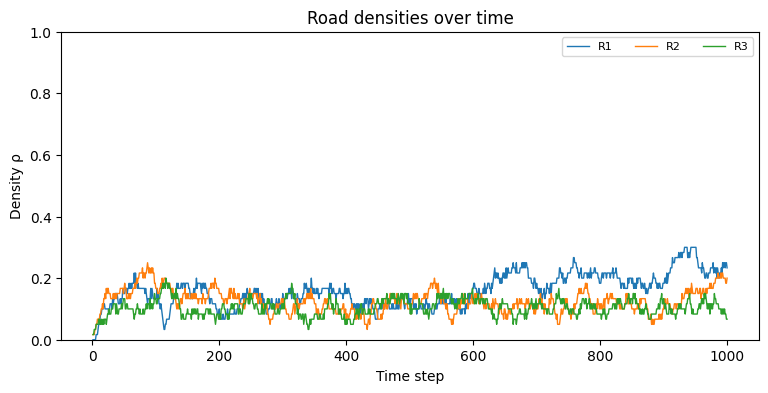

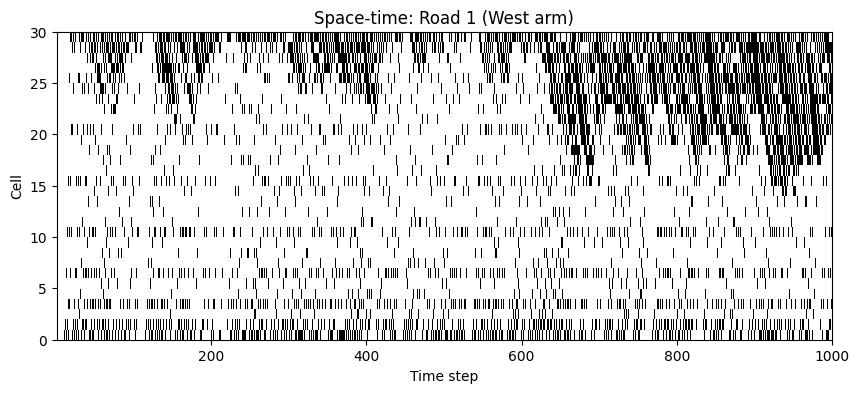

In [25]:
fig_layout, _ = plot_network_layout(result, title='T-junction network layout')
plt.show()

fig_density, _ = plot_network_density(result, title='Road densities over time')
plt.show()

fig_st, _ = plot_network_spacetime(result, road_id=1, title='Space-time: Road 1 (West arm)')
plt.show()

#### Reading the figures

Three panels are produced:

- **Network layout:** roads as line segments meeting at the junction; arrows indicate lane flow direction; $\alpha/\beta$ labels appear at the open (external) road ends. Road 1 = West arm, Road 2 = East arm, Road 3 = South stem.
- **Density time series:** mean occupancy $\rho(t)$ per road. Road 3 (stem) is typically less dense because it handles only 40% merged flow from both arms.
- **Space-time diagram (Road 1, inbound lane):** occupancy on the West arm as vehicles travel toward the junction (left to right in the lane, shown bottom-to-top in the diagram). Diagonal stripes = freely moving vehicles; vertical patches = jam events near the junction.

#### What you should see

With $p_{\text{through}}=0.6$, road 3 (the stem) receives $40\%$ of westbound traffic plus $40\%$ of eastbound traffic, whereas the other 2 recieve $60\%$ of the traffic from eachother, plus $50\%$ each from the south branch. You should see road 3 with the lowest mean density in the density time-series panel.

The junction imposes a short-lived bottleneck whenever vehicles from different arms attempt to cross simultaneously: the right-of-way logic in `evaluate_junctions` checks whether route chords on the junction perimeter intersect (a left turn conflicts with an oncoming straight-through movement). You may see brief flow dips in the current plot corresponding to these conflict resolutions. As road 2 has to give way less frequently than road 1, it typically has a slightly lower density.

#### Try it yourself

1. **Crossroads:** replace `t_junction(...)` with `crossroads(L=20, alpha=0.4, beta=0.5)`. Four arms meet at one junction; the richer routing matrix produces more complex conflict patterns and a higher chance of junction deadlocks.

2. **Saturate the junction:** increase `alpha` to 0.7 on all arms. Vehicles arrive faster than the junction can clear them — density builds up near the junction on all inbound roads and the exits per step drop.

3. **Cut the stem:** set `p_through=1.0`. All W↔E traffic continues straight and no vehicles divert to the stem — road 3 sees zero entries and stays empty. Confirm in the density time series.

4. **Roundabout:** use `roundabout(L_arm=15, L_ring=12, alpha=0.4, beta=0.5)` imported from `python.road_network`. Four T-junctions arranged in a clockwise ring with four external arms; increase `p_exit` to let vehicles leave sooner.

---
## 5. Custom Network — Asymmetric Y-Junction

The seven presets in ``python.road_network`` cover the common geometries, but you can describe any topology by hand using the ``LaneSpec``, ``RoadSpec``, and ``JunctionSpec`` dataclasses. As a worked example we'll build a Y-junction: one road feeds in from the west, then splits at junction ``J1`` into two arms — a "left" arm carrying the majority of traffic and a "right" arm carrying the rest. With unequal turning probabilities the imbalance shows up directly on the network heatmap.


#### Roads and lanes

A ``RoadSpec`` is the container for one road. It carries three things:

- ``id`` — a unique integer identifier, referenced later by junctions.
- ``end_junction`` — a pair ``(j1, j2)`` giving the junction id at each end of the road. A value of ``0`` means *open boundary* (vehicles enter or exit the network here).
- ``lanes`` — a list of ``LaneSpec`` objects, one per lane.

Each ``LaneSpec`` carries the dynamics on that lane:

| Field | Meaning |
|-------|---------|
| ``length`` | number of CA cells in the lane |
| ``flow_direction`` | ``+1`` for end_1 → end_2, ``-1`` for the reverse |
| ``alpha``, ``beta`` | entry / exit rates at the lane's open boundaries |
| ``open_in``, ``open_out`` | flags marking the lane's upstream / downstream ends as open boundaries |

For our Y we need three single-lane eastbound roads: the inflow ``R1`` is open at end_1 (with inflow rate ``alpha``), and the two outflow arms ``R2`` and ``R3`` are open at end_2 (with outflow rate ``beta``).


In [26]:
from python.road_network import LaneSpec, RoadSpec

L     = 40    # cells per road
ALPHA = 0.9   # strong inflow on R1
BETA  = 0.3   # slow outflow on both arms — backs traffic up

# R1: inflow road from the west.  Junction J1 sits at end_2.
R1 = RoadSpec(
    id=1, end_junction=(0, 1),
    lanes=[LaneSpec(length=L, flow_direction=+1,
                    alpha=ALPHA, open_in=True)],
)

# R2: "left" arm going north-east.  Junction J1 at end_1.
R2 = RoadSpec(
    id=2, end_junction=(1, 0),
    lanes=[LaneSpec(length=L, flow_direction=+1,
                    beta=BETA, open_out=True)],
)

# R3: "right" arm going south-east.  Junction J1 at end_1.
R3 = RoadSpec(
    id=3, end_junction=(1, 0),
    lanes=[LaneSpec(length=L, flow_direction=+1,
                    beta=BETA, open_out=True)],
)

print(f'Defined 3 roads: R1 (inflow), R2 (left arm), R3 (right arm).')


Defined 3 roads: R1 (inflow), R2 (left arm), R3 (right arm).


#### Joining the roads at a junction

A ``JunctionSpec`` connects roads at a single point. It carries:

- ``id`` — junction identifier.
- ``in_legs`` and ``out_legs`` — lists of ``JunctionLegSpec(road, lane, perim)`` entries identifying which ``(road, lane)`` pair flows into or out of this junction. ``lane`` is 1-based within the road's ``lanes`` list.
- ``routes`` — an ``n_in × n_out`` probability matrix; row $i$ gives the probabilities that a vehicle arriving on ``in_legs[i]`` leaves via each outbound leg. Each row must sum to 1.
- ``perim`` — clockwise perimeter port indices. Any junction that isn't a symmetric 4-way needs ``perim`` set on every leg so the right-of-way code can decide which routes cross.

For our Y the junction has one inbound leg (R1) and two outbound legs (R2 and R3). The routing matrix is a single row ``[p_left, 1 − p_left]``. Setting ``perim`` clockwise gives R1 in $= 0$, R2 out (NE) $= 1$, R3 out (SE) $= 2$.

A ``LayoutSpec`` then attaches $(x, y)$ coordinates to each junction and road endpoint. The Fortran simulator ignores it, but the visualisation helpers use it to draw the diagram.


In [27]:
from python.road_network import (
    JunctionLegSpec, JunctionSpec,
    NetworkSpec, LayoutSpec, validate,
)

P_LEFT = 0.8   # 80% of vehicles take the left (R2) arm

J1 = JunctionSpec(
    id=1, n_in=1, n_out=2,
    in_legs=[JunctionLegSpec(road=1, lane=1, perim=0)],
    out_legs=[
        JunctionLegSpec(road=2, lane=1, perim=1),
        JunctionLegSpec(road=3, lane=1, perim=2),
    ],
    routes=[[P_LEFT, 1.0 - P_LEFT]],
)

# Roads + junctions go into a NetworkSpec; the LayoutSpec carries (x, y)
# coordinates for visualisation only.
spec = NetworkSpec(roads=[R1, R2, R3], junctions=[J1])
layout = LayoutSpec(
    junctions={1: (0.0, 0.0)},
    road_endpoints={
        1: ((-1.0, 0.0), (0.0, 0.0)),
        2: (( 0.0, 0.0), (1.0,  1.0)),
        3: (( 0.0, 0.0), (1.0, -1.0)),
    },
)

# validate() raises ValueError on duplicate ids, mismatched leg counts,
# route rows that don't sum to 1, missing perim, etc.
validate(spec)
print('Spec is valid.')


Spec is valid.


#### Parameters

| Parameter | Value | Reason |
|-----------|-------|--------|
| ``L`` | 40 cells | Long enough for a backed-up arm to show a clear density gradient |
| ``ALPHA`` | 0.9 | Strong inflow — pushes R1 above its bulk capacity |
| ``BETA`` | 0.3 | Slow outflow on both arms — exits are the bottleneck |
| ``P_LEFT`` | 0.8 | 80% take the left arm, 20% the right — visibly asymmetric on the heatmap |
| ``n_steps`` | 1000 | Long enough for the asymmetric split to reach steady state |
| model | ``'NS'`` | $v_{\max}=5$, $p_{\text{slow}}=0.2$ |


In [28]:
params = SimParams(n_steps=1000, model='NS', v_max=5, p_slow=0.2, rng_seed=42)

nc_net = run_simulation(spec, params, layout, DATA_DIR / 'tutorial_y', BINARY)
result = load_network_netcdf(nc_net)

print(f'Simulation complete.  Roads: {[r.id for r in spec.roads]}')
for i, road in enumerate(spec.roads):
    rho     = result.road_density[:, i].mean()
    entries = int(result.road_entries[:, i].sum())
    exits   = int(result.road_exits[:,   i].sum())
    print(f'  Road {road.id}: mean ρ = {rho:.3f}  '
          f'total entries = {entries:5d}  exits = {exits:5d}')


Simulation complete.  Roads: [1, 2, 3]
  Road 1: mean ρ = 0.478  total entries =   356  exits =     0
  Road 2: mean ρ = 0.598  total entries =     0  exits =   206
  Road 3: mean ρ = 0.038  total entries =     0  exits =    95


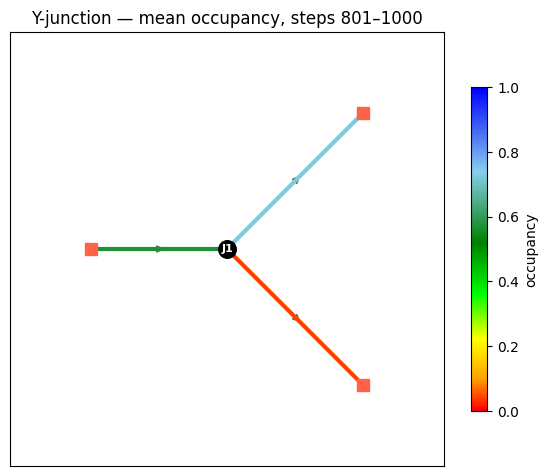

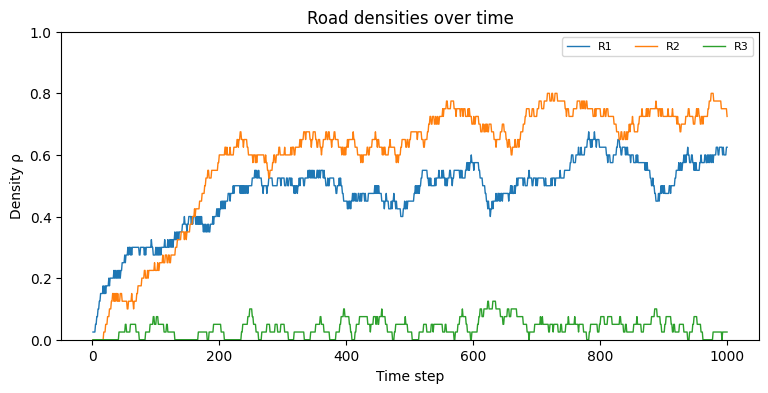

In [29]:
# Network heatmap — colour each lane by its mean occupancy over the last 200 steps.
n = result.occupancy.shape[0]
fig_hm, _ = plot_network_layout(
    result, occupancy_t=(n - 200, n - 1),
    title=f'Y-junction — mean occupancy, steps {n - 199}–{n}',
)
plt.show()

# Per-road density time series.
fig_density, _ = plot_network_density(result, title='Road densities over time')
plt.show()


#### Reading the figures

- **Network heatmap:** ``plot_network_layout`` with ``occupancy_t=(t0, t1)`` colours each lane by its mean occupancy across the requested step range. R1 (inflow, west) appears as a single arrow; R2 (NE arm) and R3 (SE arm) leave J1 in opposite vertical directions. Brighter colour = denser lane. Red squares mark the three open boundaries.
- **Density time series:** mean occupancy $\rho(t)$ per road. After a short transient R2 settles well above R3 — the ratio of the two steady-state densities reflects the routing split, modulated by the shared outflow rate $\beta$.


#### What you should see

- **R2 dominates the heatmap.** With ``P_LEFT=0.8`` and ``BETA=0.3`` the left arm receives four times as many vehicles as the right and the slow exit lets them pile up — R2 sits at $\rho \approx 0.6$ while R3 stays around $\rho \approx 0.04$.
- **R1 backs up** because R2 is saturated: J1 can only forward a vehicle into R2 when R2's first cell is empty, so back-pressure propagates upstream.
- Total throughput (R2 exits + R3 exits) approximately matches the inflow at R1, modulo the in-transit population on the three arms.


#### Try it yourself

1. **Symmetric split:** set ``P_LEFT = 0.5`` and rerun. Both arms carry identical traffic and the heatmap shows them at the same colour.
2. **Sweep ``P_LEFT``** from 0.95 down to 0.5 and watch the contrast between R2 and R3 fade — the two arms cross at $p_L = 0.5$.
3. **Drain quickly:** set ``BETA = 0.9``. The arms no longer back up; the routing split is still there but the heatmap is dim everywhere.
4. **Promote it to a preset:** wrap the construction above in a function returning ``(spec, layout)`` and add it to ``PRESETS`` in ``src/python/road_network.py``. The GUI will pick it up automatically.
